# **Credit Card Transactions Fraud Detection: Random Forest vs XGBoost vs CatBoost💳**

# **Project Overview**

This project aims to build machine learning models for Credit card fraud detection using supervised learning models in different algorithms including 

1) Random Forest
2) XGBoost
3) CatBoost 

to compare performance and give practical recommendations and implications. This project presents how to address the imbalance in data, stop financial loss from fraudulent activities by accurately identifying fraudulent transactions and minimising false alarms with tuning the hyperparameter and the decision threshold.

---

Machine Learning Model Building Pipeline including:

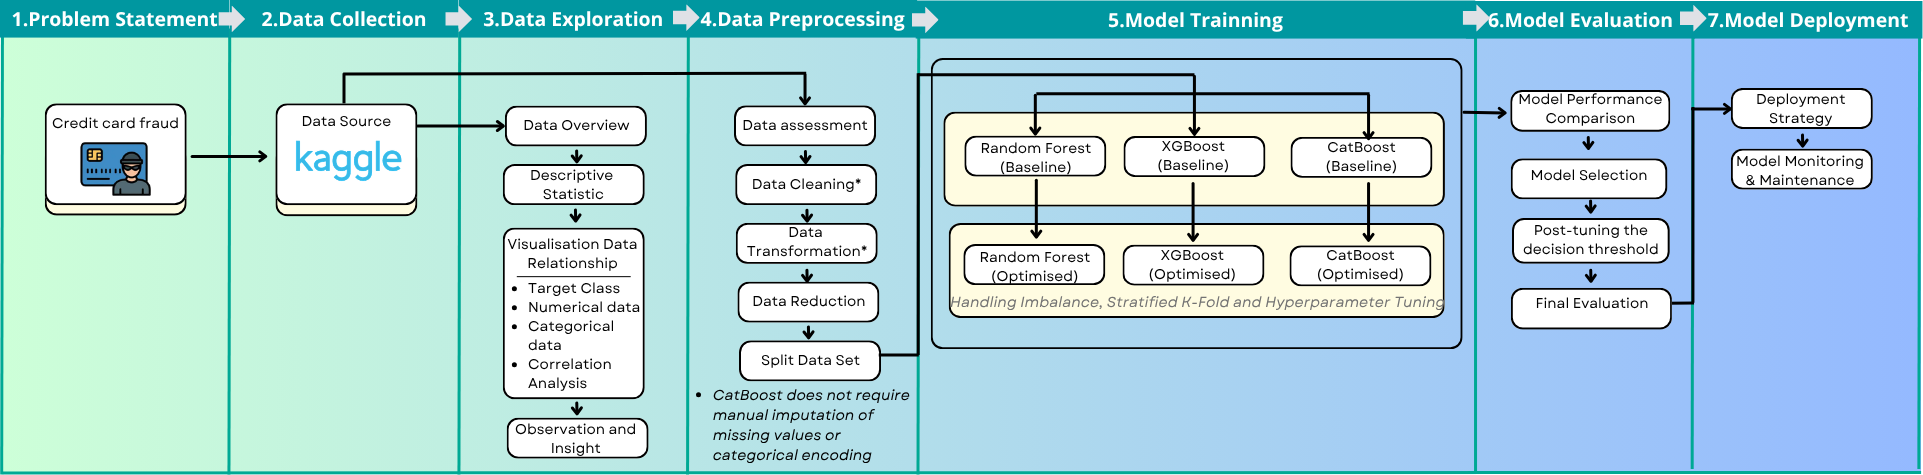



**I developed this project to practice data analytics skill and learning machine learning. If you have any suggestions or feedback, I would be very thank you for your help to improve my project and skills 😊.**

---


# **1.Problem Statement**

Financial Fraud is still a significant global challenge and is increasing. Because advanced artificial intelligence is being used in fraud tactics, reshaping the contours of financial crime. While Artificial intelligence and machine learning have become significantly part of fraud detection to predict and indicate the fraudulent activity pattern. Credit card fraud is a type of financial fraud that involves the unauthorised use of a credit card to make fraudulent transactions. There are many machine learning algorithms to build a model for Credit card fraud detection as a detection control and develop for real-time fraud detection.

This project aims to build machine learning models for Credit card fraud detection using supervised learning models in different algorithms to compare performance and give practical recommendations and implications.


<hr style="border: none; border-top: 5px double #333;">


# **2.Data Collection**

The dataset used in this study is “Credit Card Transactions Fraud Detection Dataset “ from Kaggle, containing legitimate and fraudulent transactions between 1 January 2019 and 31st Dec 2020, containing  21 features such as transaction date and time, merchan, category, amount and customer information. The target variable, is_fraud, indicates whether a transaction is fraudulent (1) or not (0). In the case of the real-world situation, all entries have been anonymised to protect customer privacy.

**Importing Libraries**

In [10]:
# For installing xgboost
!pip install xgboost

In [11]:
# For installing CatBoost 
!pip install catboost

In [12]:
# For installing and updating scikit-learn
! pip install -U scikit-learn


In [217]:
# 1. Data manipulation & Calculation
import pandas as pd
import numpy as np

# 2. Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Data preparation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 4. Machine learning algorithms
import time
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# 5. Model Improvement & Tuning
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.model_selection import TunedThresholdClassifierCV

# 6. Model evaluation
import sklearn
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve,
    accuracy_score, roc_auc_score, average_precision_score, 
    auc, precision_score, recall_score, f1_score, make_scorer
)

**Downloading Data**

In [15]:
#Upload Dataset

df_train = pd.read_csv('fraudTrain.csv', index_col=0)
df_test = pd.read_csv('fraudTest.csv', index_col=0)
df_full = pd.concat([df_train, df_test], axis=0)

<hr style="border: none; border-top: 5px double #333;">

# **3.Data Exploration**

## **3.1)Data Overview** 

In [19]:
# combining all train and test data for data assessment 
df_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1852394 entries, 0 to 555718
Data columns (total 22 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   trans_date_trans_time  object 
 1   cc_num                 int64  
 2   merchant               object 
 3   category               object 
 4   amt                    float64
 5   first                  object 
 6   last                   object 
 7   gender                 object 
 8   street                 object 
 9   city                   object 
 10  state                  object 
 11  zip                    int64  
 12  lat                    float64
 13  long                   float64
 14  city_pop               int64  
 15  job                    object 
 16  dob                    object 
 17  trans_num              object 
 18  unix_time              int64  
 19  merch_lat              float64
 20  merch_long             float64
 21  is_fraud               int64  
dtypes: float64(5), int64(5),

In [20]:
# View how many rows and columns
print(f"data Shape: {df_full.shape}")

data Shape: (1852394, 22)


In [21]:
# View the first 5 rows to confirm data set is loaded correctly
df_full.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


After explore data, I will prepare the features as follows

| No. | Feature | Description and Strategy for Data Preprocessing |
|:---:|:---|:---|
| 1 | **trans_date_trans_time** | Timestamp of the transaction. <br> *Strategy:* Extract temporal features like hour of the day, day of the week, or month. |
| 2 | **cc_num** | Credit card number of the customer. <br> *Strategy:* Drop column due to high cardinality and uniqueness. |
| 3 | **merchant** | Name of the merchant. <br> *Strategy:* Drop column due to high cardinality and uniqueness. |
| 4 | **category** | Category of the transaction (e.g., entertainment, food_dining). <br> *Strategy:* Use *Label Encoding* for Random Forest and XGBoost. |
| 5 | **amt** | Transaction amount (numerical value). <br> *Strategy:* Keep as a numerical feature. |
| 6 | **first, last** | First and last name of the cardholder. <br> *Strategy:* Drop column due to high cardinality and uniqueness. |
| 7 | **gender** | Gender of the cardholder. <br> *Strategy:* Use *Label Encoding* for Random Forest and XGBoost. |
| 8 | **street, city, state, zip** | Address details of the cardholder. <br> *Strategy:* Drop column due to high cardinality. |
| 9 | **lat, long** | Latitude and Longitude of the cardholder. <br> *Strategy:* Create new feature *"Distance"* by calculating distance between cardholder and merchant. |
| 10 | **city_pop** | Population of the cardholder's city. <br> *Strategy:* Keep as a numerical feature. |
| 11 | **job** | Job title/profession of the cardholder. <br> *Strategy:* Drop column due to high cardinality. |
| 12 | **dob** | Date of birth of the cardholder. <br> *Strategy:* Create new feature *"Age"* by calculating from the transaction date. |
| 13 | **trans_num** | Unique identifier for the transaction. <br> *Strategy:* Drop column due to high cardinality. |
| 14 | **unix_time** | Transaction time in Unix format. <br> *Strategy:* Drop column due to high cardinality. |
| 15 | **merch_lat, merch_long** | Latitude and Longitude of the merchant. <br> *Strategy:* Use to calculate the *"Distance"* feature. |
| 16 | **is_fraud** | **Target Variable**: 1 if fraudulent, 0 otherwise. |

---

## **3.2) Descriptive Statistic**

In [25]:
# View data summary statistic
display(df_full.describe().T)

,count,mean,std,min,25%,50%,75%,max
cc_num,1852394.0,4.173860e+17,1.309115e+18,6.041621e+10,1.800429e+14,3.521417e+15,4.642255e+15,4.992346e+18
amt,1852394.0,7.006357e+01,1.592540e+02,1.000000e+00,9.640000e+00,4.745000e+01,8.310000e+01,2.894890e+04
zip,1852394.0,4.881326e+04,2.688185e+04,1.257000e+03,2.623700e+04,4.817400e+04,7.204200e+04,9.992100e+04
lat,1852394.0,3.853931e+01,5.071470e+00,2.002710e+01,3.466890e+01,3.935430e+01,4.194040e+01,6.669330e+01
long,1852394.0,-9.022783e+01,1.374789e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.015800e+01,-6.795030e+01
city_pop,1852394.0,8.864367e+04,3.014876e+05,2.300000e+01,7.410000e+02,2.443000e+03,2.032800e+04,2.906700e+06
unix_time,1852394.0,1.358674e+09,1.819508e+07,1.325376e+09,1.343017e+09,1.357089e+09,1.374581e+09,1.388534e+09
merch_lat,1852394.0,3.853898e+01,5.105604e+00,1.902742e+01,3.474012e+01,3.936890e+01,4.195626e+01,6.751027e+01
merch_long,1852394.0,-9.022794e+01,1.375969e+01,-1.666716e+02,-9.689944e+01,-8.744069e+01,-8.024511e+01,-6.695090e+01
is_fraud,1852394.0,5.210015e-03,7.199217e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


In [26]:
# View Feature Names and its Datatypes
df_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1852394 entries, 0 to 555718
Data columns (total 22 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   trans_date_trans_time  object 
 1   cc_num                 int64  
 2   merchant               object 
 3   category               object 
 4   amt                    float64
 5   first                  object 
 6   last                   object 
 7   gender                 object 
 8   street                 object 
 9   city                   object 
 10  state                  object 
 11  zip                    int64  
 12  lat                    float64
 13  long                   float64
 14  city_pop               int64  
 15  job                    object 
 16  dob                    object 
 17  trans_num              object 
 18  unix_time              int64  
 19  merch_lat              float64
 20  merch_long             float64
 21  is_fraud               int64  
dtypes: float64(5), int64(5),

In [27]:
df_full.nunique()

trans_date_trans_time    1819551
cc_num                       999
merchant                     693
category                      14
amt                        60616
first                        355
last                         486
gender                         2
street                       999
city                         906
state                         51
zip                          985
lat                          983
long                         983
city_pop                     891
job                          497
dob                          984
trans_num                1852394
unix_time                1819583
merch_lat                1754157
merch_long               1809753
is_fraud                       2
dtype: int64

---

## **3.3) Visualisation Data Relationship**

### **Data Visualisation for Target Class** 

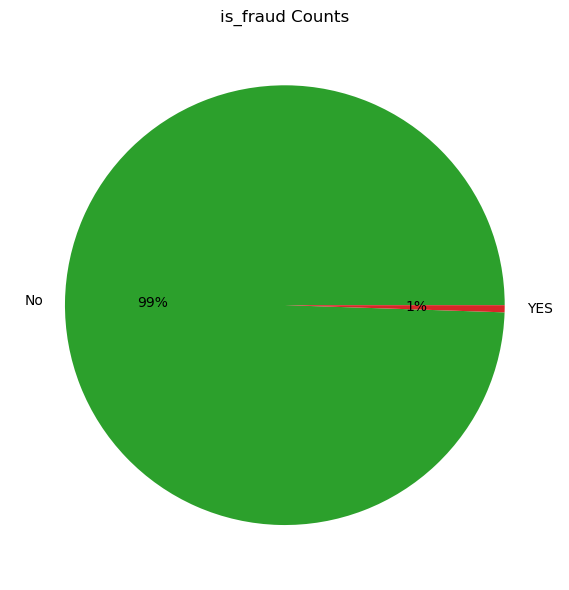

In [31]:
# Data Analysis and Visualization targe class
counts = df_full["is_fraud"].value_counts()
plt.figure(figsize=(12, 6))
plt.pie(counts, labels=["No", "YES"], colors=['tab:green', 'tab:red'], autopct="%0.0f%%")
plt.title("is_fraud Counts")
plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()

After visualising the data set, the figure shows an imbalance, with no fraud comprising 99%, and fraud comprising 1%. Therefore, the imbalanced data is a challenge to address in the step of data preprocessing

---

### **Data Visualisation for Numerical data** 

In [34]:
# Define a function to plot histograms in difference target classes
def plot_split_histograms(df, feature, target, figsize=(10, 4), bins=20, colors=['tab:green', 'tab:red']):
    # Group Identification
    labels = sorted(df[target].unique())
    n_labels = len(labels)
    
    # Create subplots
    fig, axes = plt.subplots(1, n_labels, figsize=figsize)
    if n_labels == 1:
        axes = [axes]
        
    # Iterative Plotting Loop   
    for i, label in enumerate(labels):
        subset = df[df[target] == label]
        
        subset[feature].plot(
            kind='hist',
            ax=axes[i],
            color=colors[i % len(colors)],
            edgecolor='black',
            bins=bins)
        
        target_name = "Legitimate" if label == 0 else "Fraud" 
        axes[i].set_title(f'Status: {target_name} (n={len(subset)})', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(feature.replace('_', ' ').capitalize())
        axes[i].set_ylabel('Transaction Count')
        axes[i].legend()
        axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

In [35]:
# Define a function for box plot
def plot_boxplot(df, feature, target, colors=['tab:green', 'tab:red']):
    plt.figure(figsize=(6, 6))
    sns.boxplot(data=df, x=target, y=feature, palette=colors, hue=target, legend=False)
    plt.title(f'Comparison of {feature.capitalize()} by Transaction Status', fontsize=14, pad=15)
    plt.xlabel('Transaction Type (0: Legitimate, 1: Fraud)', fontsize=12)
    plt.ylabel(f'{feature.capitalize()}', fontsize=12)
    plt.xticks([0, 1], ['Legitimate (0)', 'Fraud (1)'])
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

#### **Age📊**

In [37]:
# Customer Age Extraction
def age_extraction(df):
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])   #  Converting to Datetime Objects
    df['dob'] = pd.to_datetime(df['dob'])
    df['age'] = df['trans_date_trans_time'].dt.year - df['dob'].dt.year    
    return df

df_full = age_extraction(df_full)

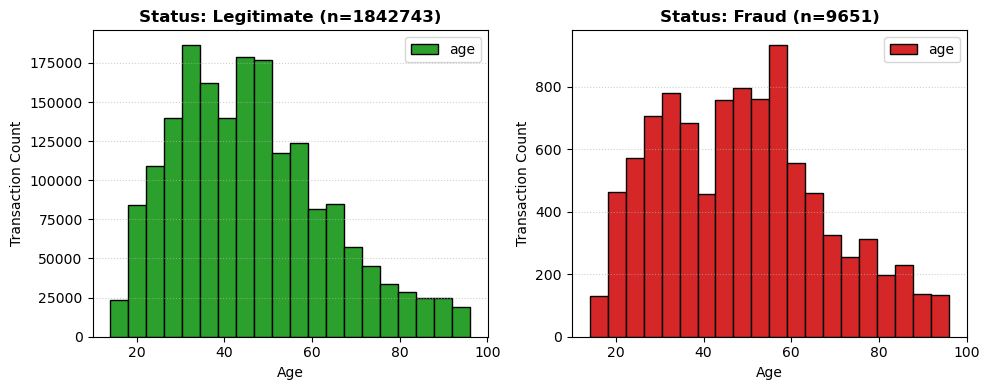

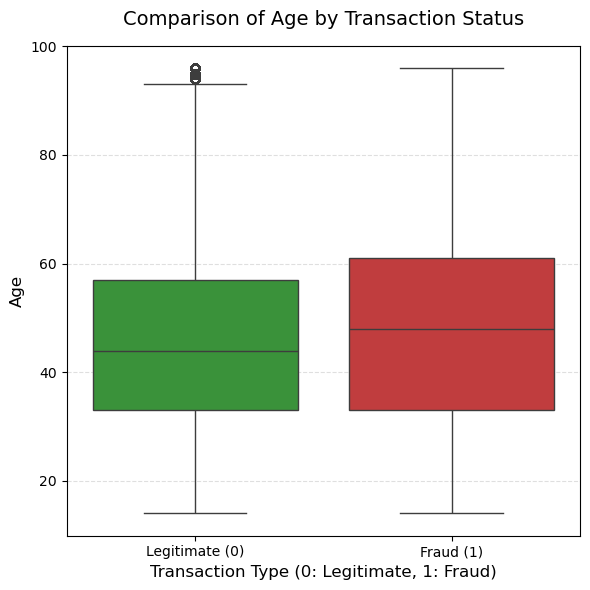

In [38]:
plot_split_histograms(df_full, 'age', 'is_fraud')
plot_boxplot(df_full, 'age', 'is_fraud')

***Observation***
The histograms illustrate the age distribution across the two target classes: legitimate and fraudulent. Legitimate transactions follow a normal distribution, peaking between ages 30 and 45. In contrast, the fraudulent class displays a bimodal distribution, with distinct peaks at 30 and 55 years. Furthermore, the box plot reveals a wider age range and a higher median age for customers affected by fraud compared to those engaging in legitimate activity.

***Key Insights***
It seems that the elderly users are more frequently targeted by fraud activity 

---

#### **Transaction Amount📊**

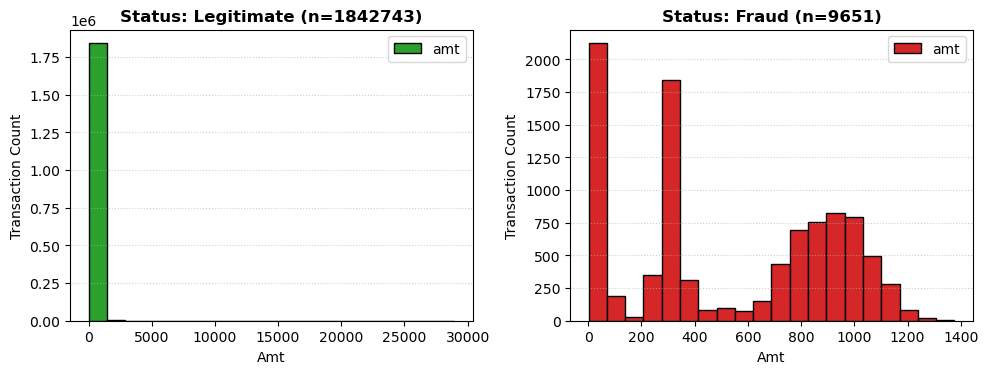

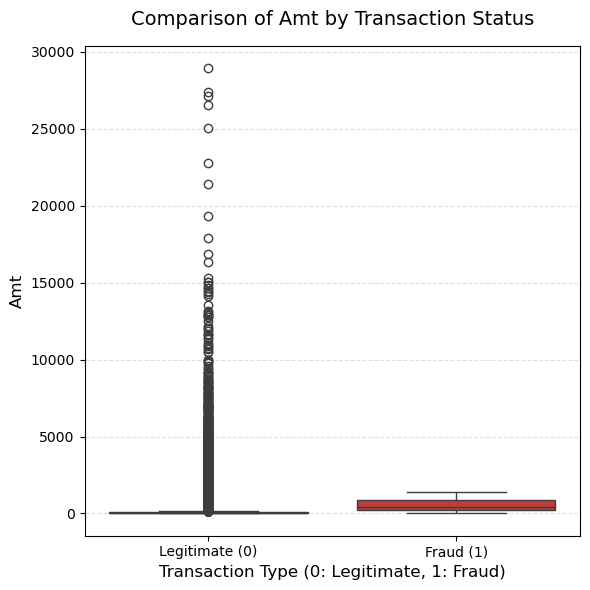

In [41]:
plot_split_histograms(df_full, 'amt', 'is_fraud')
plot_boxplot(df_full, 'amt', 'is_fraud')

***Observation***
The analysis of the transaction amount displays behavioural patterns between the two classes. Legitimate transactions are characterised by extreme positive skewness. The majority of the transaction amounts are near zero, but also have outliers. In contrast, fraudulent activity is strictly below £ 1,400. 

***Key Insights***
Legitimate transactions exhibit high variability, reflecting diverse consumer behaviors. While the vast majority of these transactions involve small amounts, there are occasional extreme outliers representing high-value purchases. In contrast, fraudulent transactions are strictly capped at approximately £1,400. This suggests that perpetrators deliberately avoid higher amounts to bypass automated preventive controls.

---

#### **City Population📊**

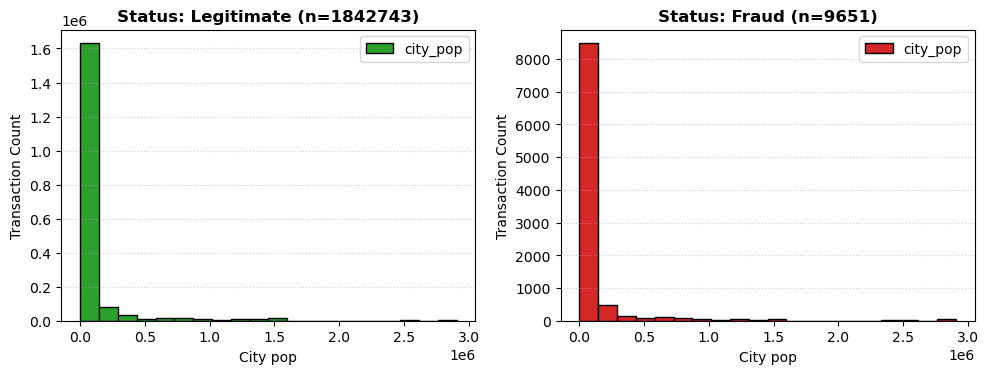

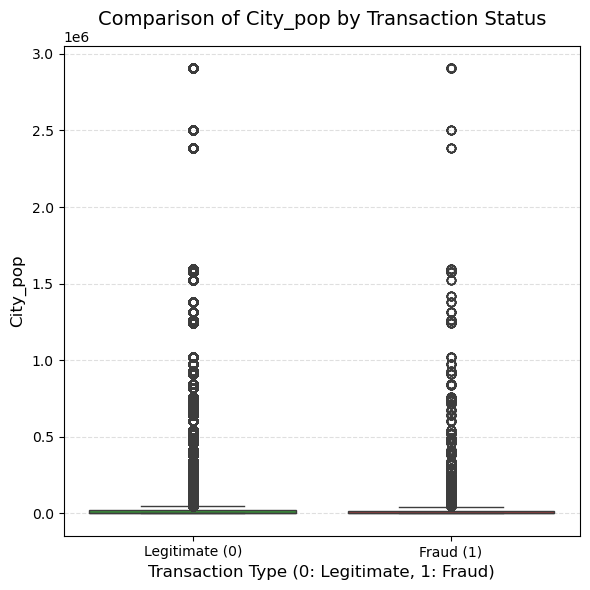

In [44]:
plot_split_histograms(df_full, 'city_pop', 'is_fraud')
plot_boxplot(df_full, 'city_pop', 'is_fraud')

***Observation***
The histogram illustrates that the vast majority of both legitimate and fraud transaction occur in cities with low populations. Moreover, the box plot displays that both legitimate and fraudulent transactions exhibit nearly identical density, median values, and interquartile ranges.

***Key Insights***
This suggests that population size alone is not a strong to inditify for fraud in this dataset. Moreover, Fraudulent is not specifically targeting big cities or small towns.

---

#### **Distance between customer's location and merchant's location📈**

In [47]:
# Distant Extraction by using Haversine Formula to calculate the distance between two locations
def calculate_haversine(df):
    # Transform Degrees to Radians
    lat1, lon1 = np.radians(df['lat']), np.radians(df['long'])
    lat2, lon2 = np.radians(df['merch_lat']), np.radians(df['merch_long'])

    # The differences between 2 points
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    # Calculate the square of half the chord length
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2

    #Calculate Angular distance
    c = 2 * np.arcsin(np.sqrt(a))

    # Calculate the distance (Km.)
    r = 6371 #Earth radius
    return c * r

# Driver code
df_full['distance_km'] = calculate_haversine(df_full)

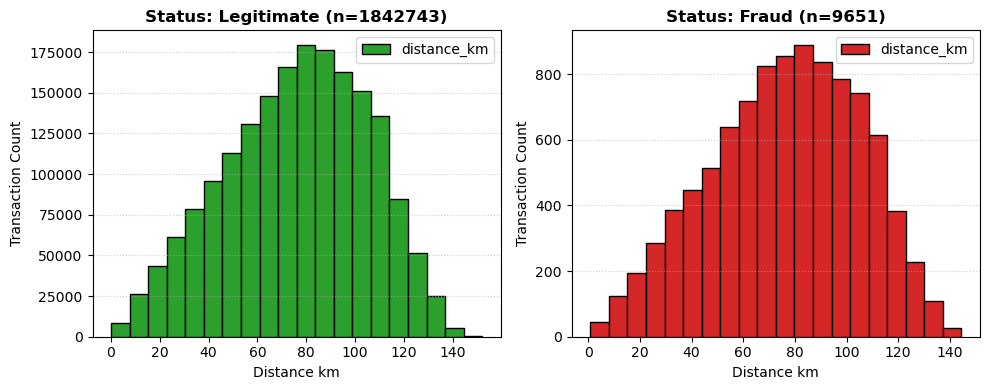

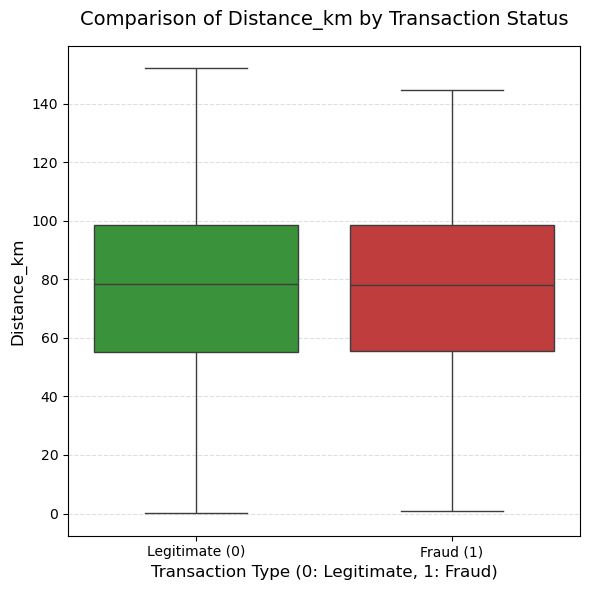

In [48]:
plot_split_histograms(df_full, 'distance_km', 'is_fraud')
plot_boxplot(df_full, 'distance_km', 'is_fraud')

***Observation***
The histogram illustrates that both legitimate and fraudulent transactions build up steadily and peak at exactly the same spot around 80 km before decreasing.
The box plot displays that the median line for both classes is identical between 78 and 80 km. Moreover, the range of data is over the exact same territory, from 0 to roughly 150 km.

***Key Insights***
This suggests that distance does not appear to be a red flag to commit fraud activity.

---

### **Data Visualisation for categorical data** 

In [51]:
# Define a function to plot the bar chart
def plot_split_bar_charts(df, feature, target, figsize=(14, 5), colors=['tab:green', 'tab:red']):
    labels = sorted(df[target].dropna().unique())
    n_labels = len(labels)
    
    # create subplots 
    fig, axes = plt.subplots(1, n_labels, figsize=figsize)
    
    if n_labels == 1:
        axes = [axes]
        
    for i, label in enumerate(labels):
        subset = df[df[target] == label]
        
        # Plot bar chart by countplot from seaborn and order the data for comparison
        order = df[feature].value_counts().index
        sns.countplot(
            data=subset, 
            y=feature, 
            ax=axes[i], 
            hue=feature,         
            legend=False,        
            palette=[colors[i % len(colors)]] * len(order), 
            order=order,
            edgecolor='black')
        target_name = "Legitimate" if label == 0 else "Fraud"
        axes[i].set_title(f'Status: {target_name} (n={len(subset)})', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Transaction Count')
        axes[i].set_ylabel(feature.replace('_', ' ').capitalize())
        axes[i].grid(axis='x', linestyle=':', alpha=0.6)
    
    plt.suptitle(f'Comparison of {feature.capitalize()} Distribution', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

#### **Category📊**

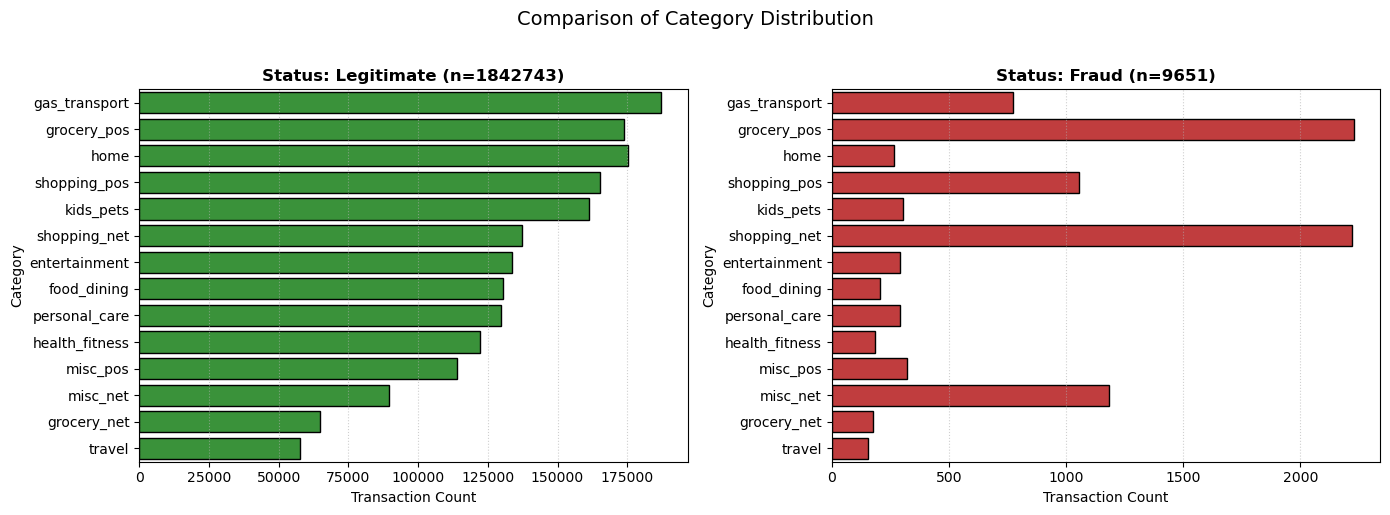

In [53]:
plot_split_bar_charts(df_full, 'category', 'is_fraud')

***Observation***
The bar charts display that Legitimate transactions are primarily driven by daily necessities and high-frequency utility categories such as gas_transport and home. Conversely, fraudulent activity shows a concentration in grocery_pos, shopping_net, and misc_net.

***Key Insights***
The high frequency in 'Net' (Online) and 'Miscellaneous' categories suggests that online transactions are the target of fraud because they are difficult to trace.

---

#### **Gender📊**

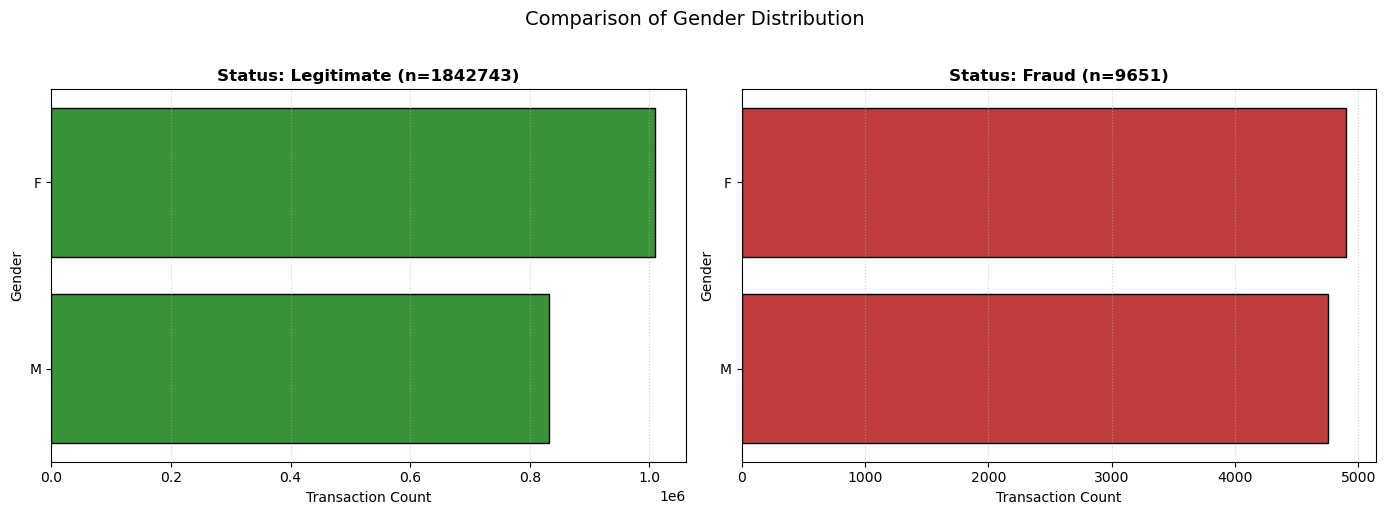

In [56]:
plot_split_bar_charts(df_full, 'gender', 'is_fraud')

***Observation***
The charts demonstrate that the gender distribution remains consistent across both legitimate and fraudulent transactions. The amount of feamale is higher than male for both cases.

***Key Insights***
This symmetry suggests that gender is not a discriminative feature for fraud detection in this dataset

---

#### **State📊**

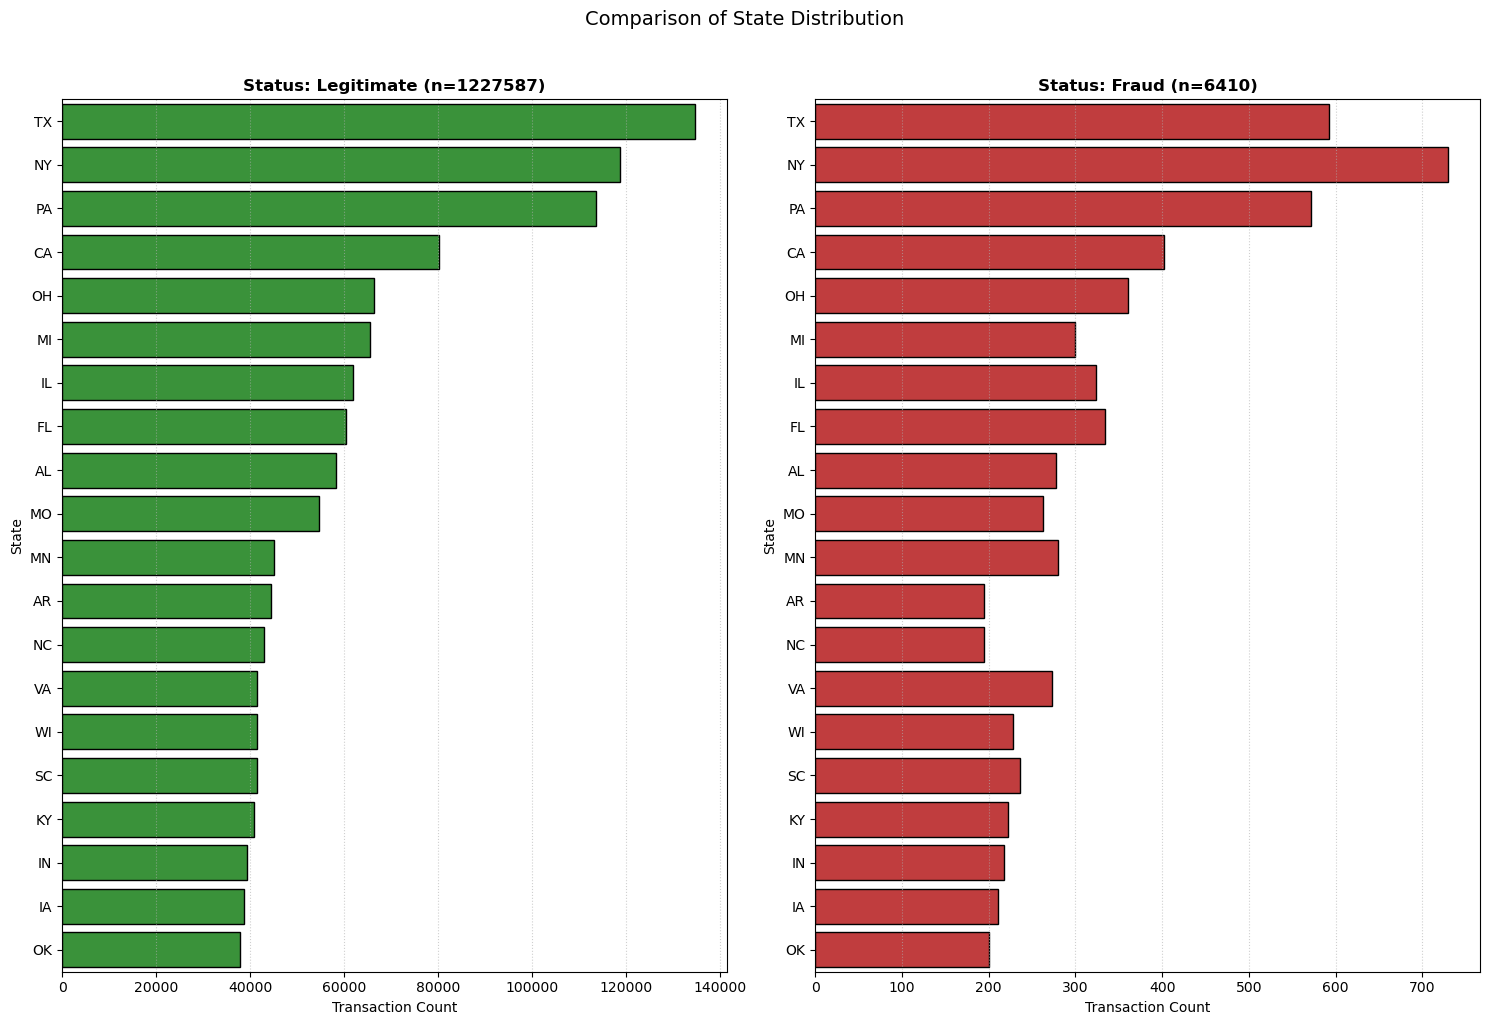

In [59]:
# Top 20 state which have highest transaction amount
top_20_categories = df_full['state'].value_counts().nlargest(20).index

df_top20 = df_full[df_full['state'].isin(top_20_categories)]

plot_split_bar_charts(df_top20, 'state', 'is_fraud', figsize=(15, 10))

***Observation***
The bar charts indicate that the top three states for transaction volume, including TX, NY, and PA, remain consistent across both classes. However, a significant shift occurs in the rankings. Texas leads in legitimate transactions, while New York (NY) exhibits the highest frequency of fraudulent cases

***Key Insights***
According to the highest frequency of fraudulent cases at New York State, it suggests a higher fraud risk concentration.


---

#### **Hour📊**

In [62]:
# DateTime Extraction
def datetime_extraction(df):
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])   #  Converting to Datetime Objects
    df['hour'] = df['trans_date_trans_time'].dt.hour                            #  Extracting DateTime to hour
    df['day'] = df['trans_date_trans_time'].dt.day                              #  Extracting DateTime to day
    df['month'] = df['trans_date_trans_time'].dt.month                          #  Extracting DateTime to month
    df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek                #  Extracting DateTime to day of week
    return df

df_full = datetime_extraction(df_full)

In [63]:
# Define a function to plot the bar chart which is ordered by number 
def plot_split_bar_charts_sorted(df, feature, target, figsize=(16, 8), colors=['tab:green', 'tab:red']):
    sorted_order = sorted(df[feature].unique())
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    labels = [0, 1]
    for i, label in enumerate(labels):
        subset = df[df[target] == label]
        
        sns.countplot(
            data=subset, 
            y=feature, 
            ax=axes[i], 
            order=sorted_order,    
            hue=feature,           
            legend=False,          
            palette=[colors[i]] * len(sorted_order), 
            edgecolor='black'
        )
        status_text = "Legitimate" if label == 0 else "Fraud"
        axes[i].set_title(f'Status: {status_text} (n={len(subset)})', fontsize=13, fontweight='bold')
        axes[i].set_xlabel('Transaction Count')
        axes[i].set_ylabel(feature.replace('_', ' ').capitalize())
        axes[i].grid(axis='x', linestyle=':', alpha=0.6)

    plt.suptitle(f'Behavioral Analysis: Transaction Count by {feature.capitalize()}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

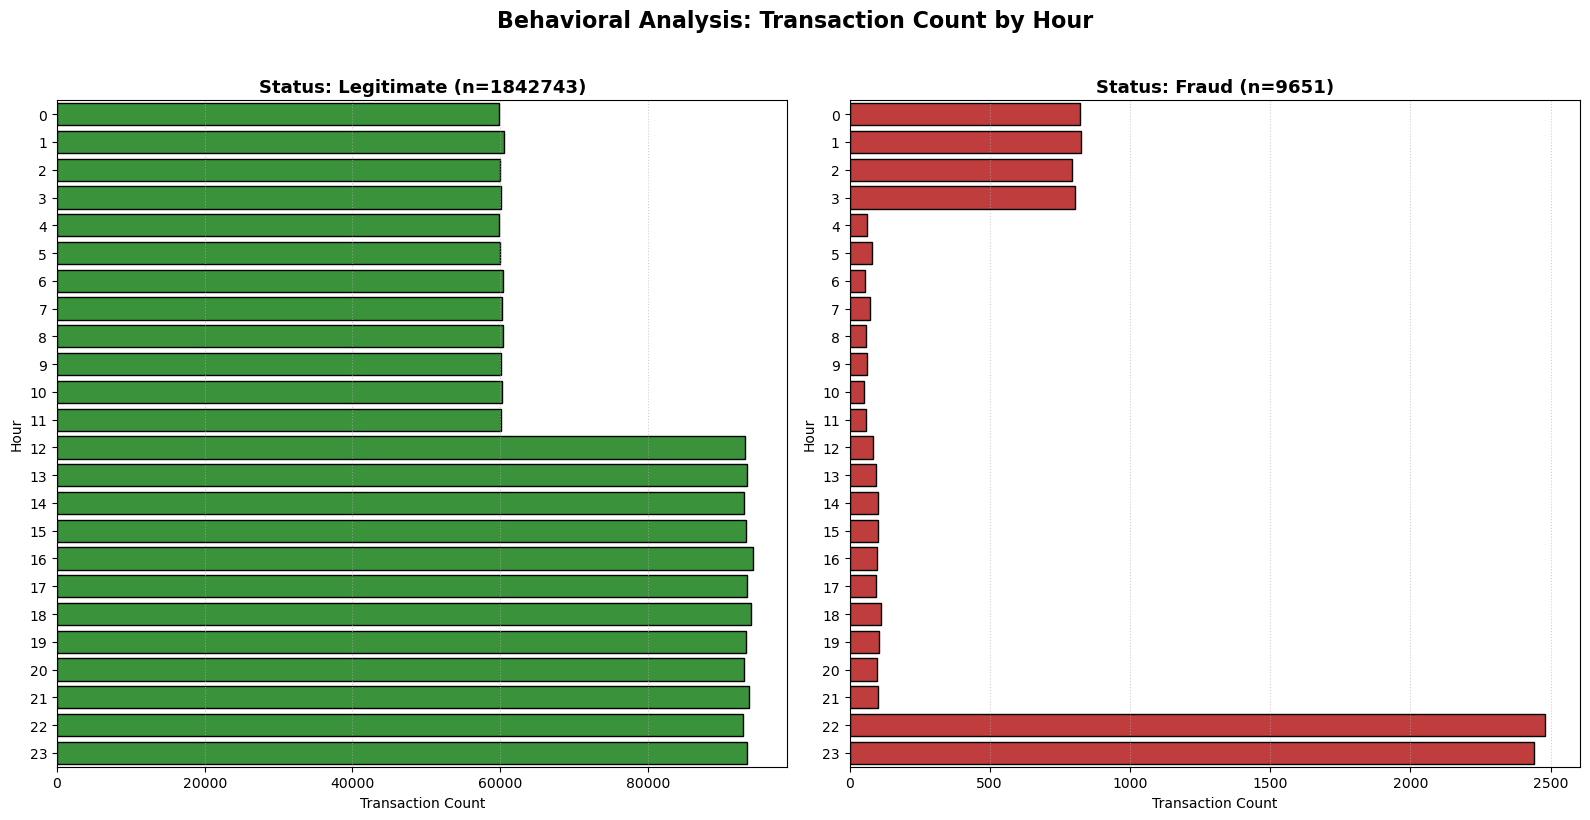

In [64]:
plot_split_bar_charts_sorted(df_full, 'hour', 'is_fraud')

***Observation***
The charts indicate that legitimate transaction volume remains high from midday through midnight. However, fraudulent activity shows a distinct concentration during the late-night and early-morning hours, specifically between 22:00 and 03:00.

***Key Insights***
The fraud transactions usually occur during the late-night and early-morning hours, when cardholders are less likely to monitor their accounts.

---

#### **Day📊**

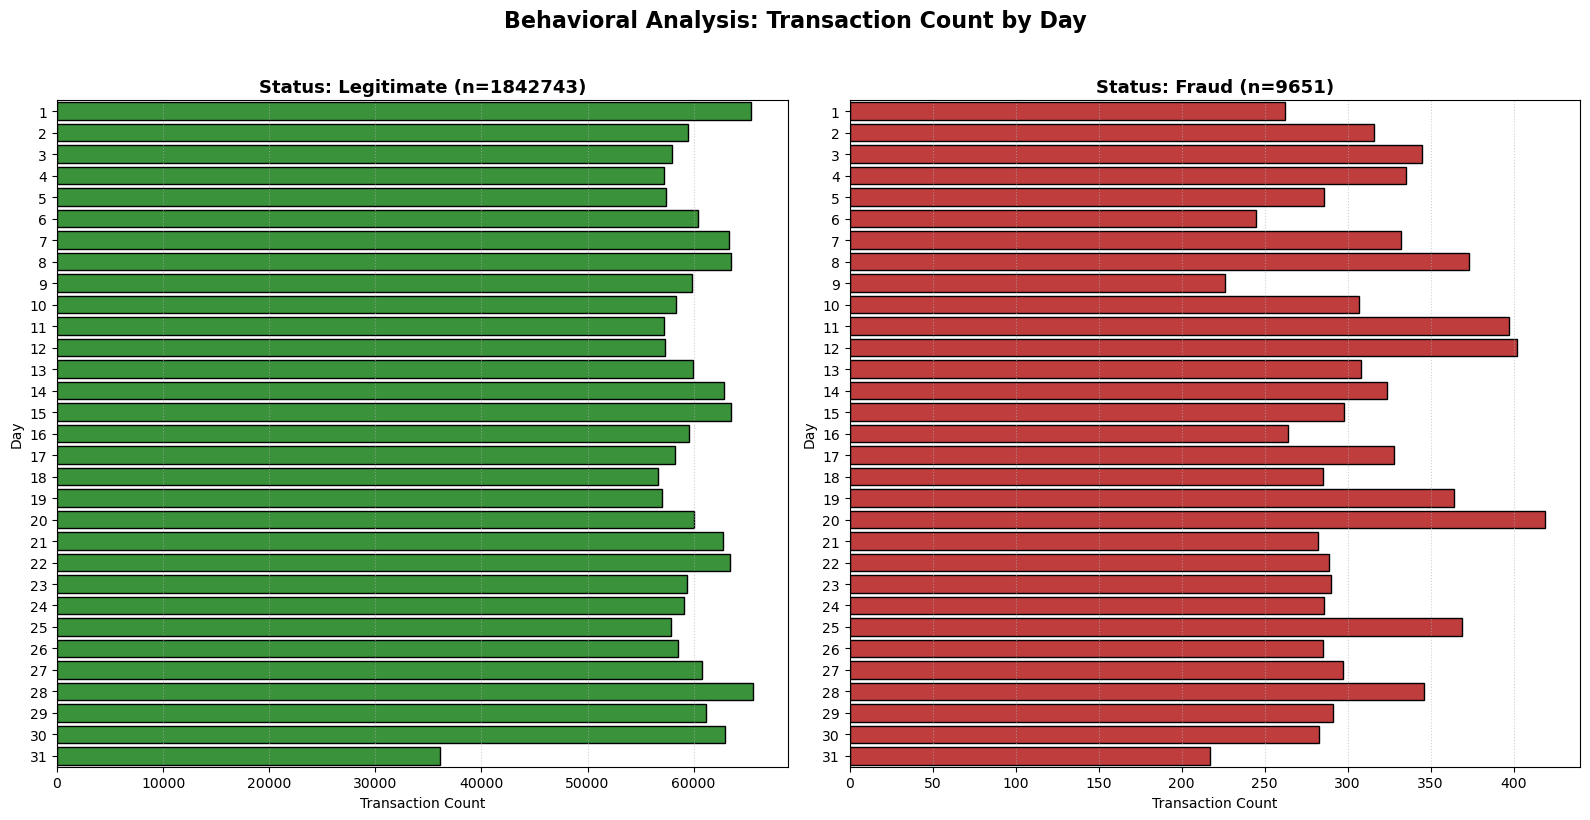

In [67]:
plot_split_bar_charts_sorted(df_full, 'day', 'is_fraud')

***Observation***
The charts illustrate that the probability of fraud is consistently spread throughout the month

***Key Insights***
There is no significant correlation between the day of the month and the frequency of fake transactions

---

#### **Day of Week📊**

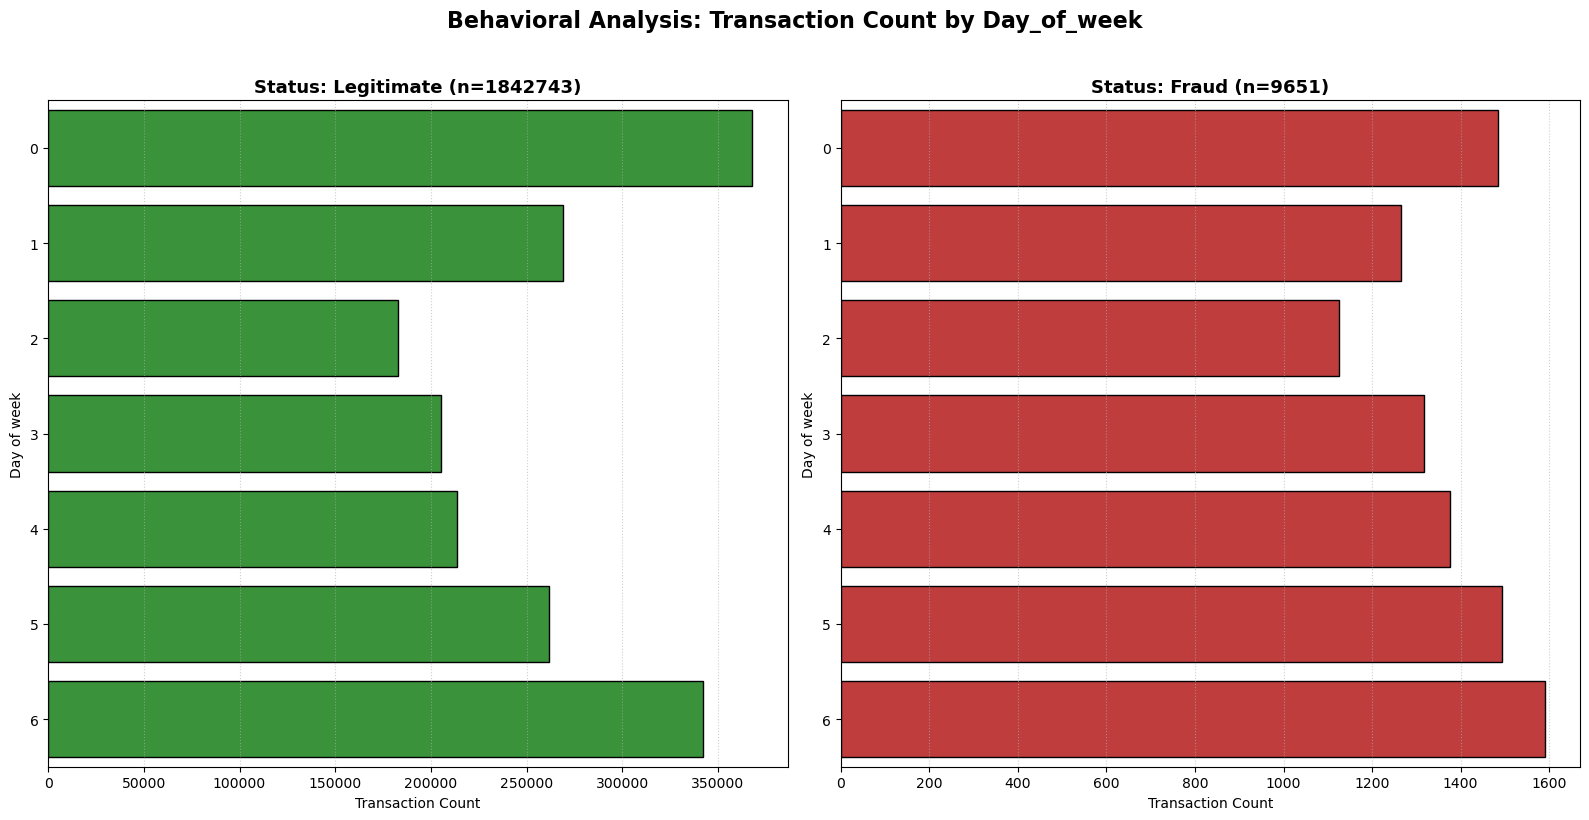

In [70]:
plot_split_bar_charts_sorted(df_full, 'day_of_week', 'is_fraud')

***Observation***
The charts reveal that while legitimate transactions peak on Mondays and Sundays, fraudulent activity steadily increases throughout the week, reaching its highest point on Sunday.

***Key Insights***
This suggests that fraudsters may take advantage of the increased transaction volume and relaxed monitoring typical of the weekend period

---

#### **Month📊**

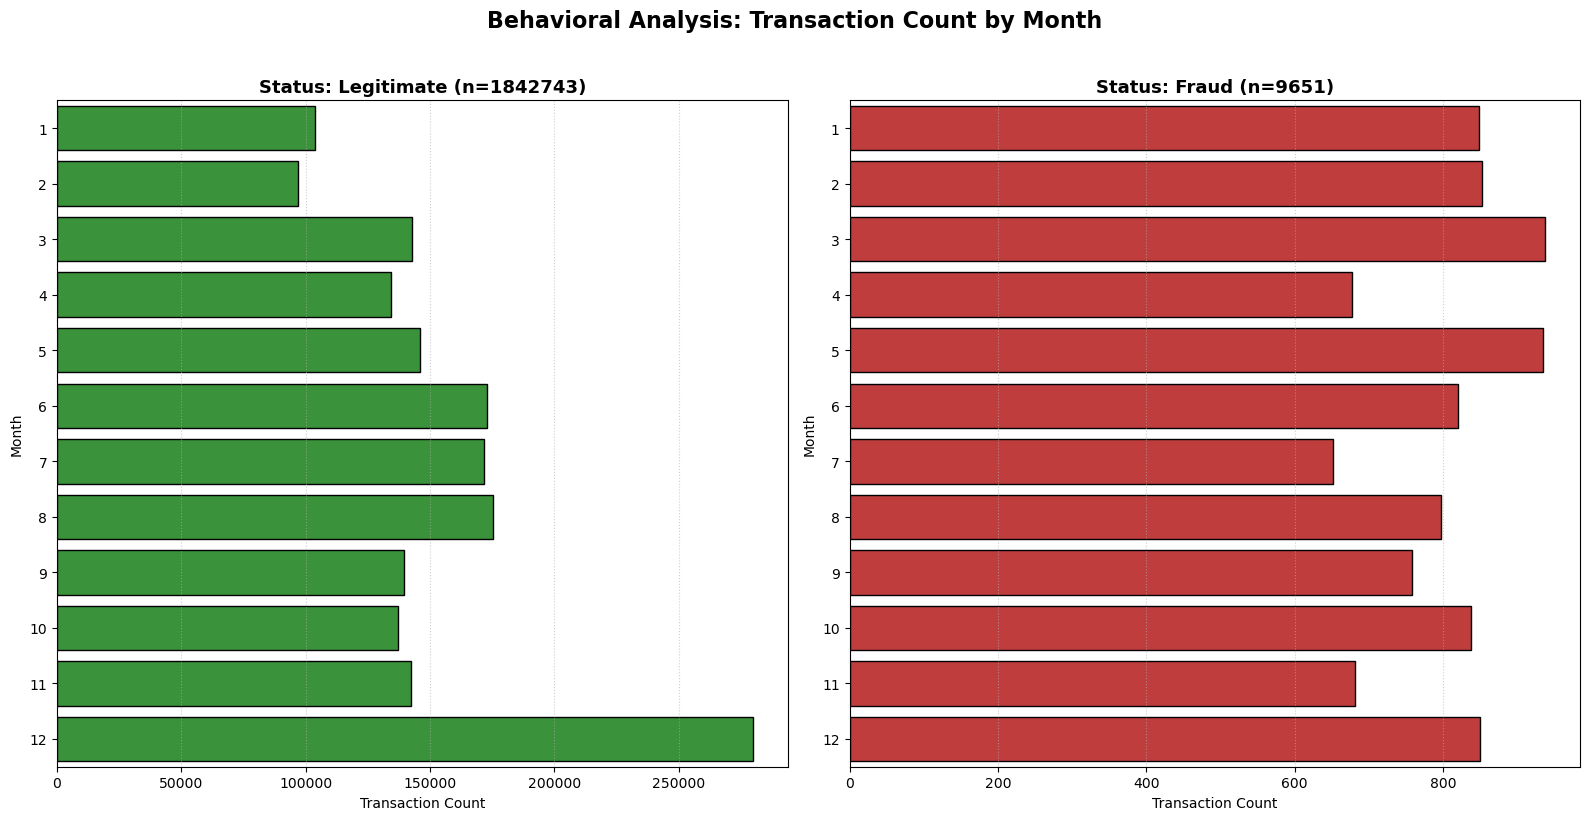

In [73]:
plot_split_bar_charts_sorted(df_full, 'month', 'is_fraud')

***Observation***
The charts illustrate that the probability of fraud is consistently spread throughout the year

***Key Insights***
There is no significant correlation between the day of the year and the frequency of fake transactions

---

### **Data Visualisation by Correlation Analysis** 

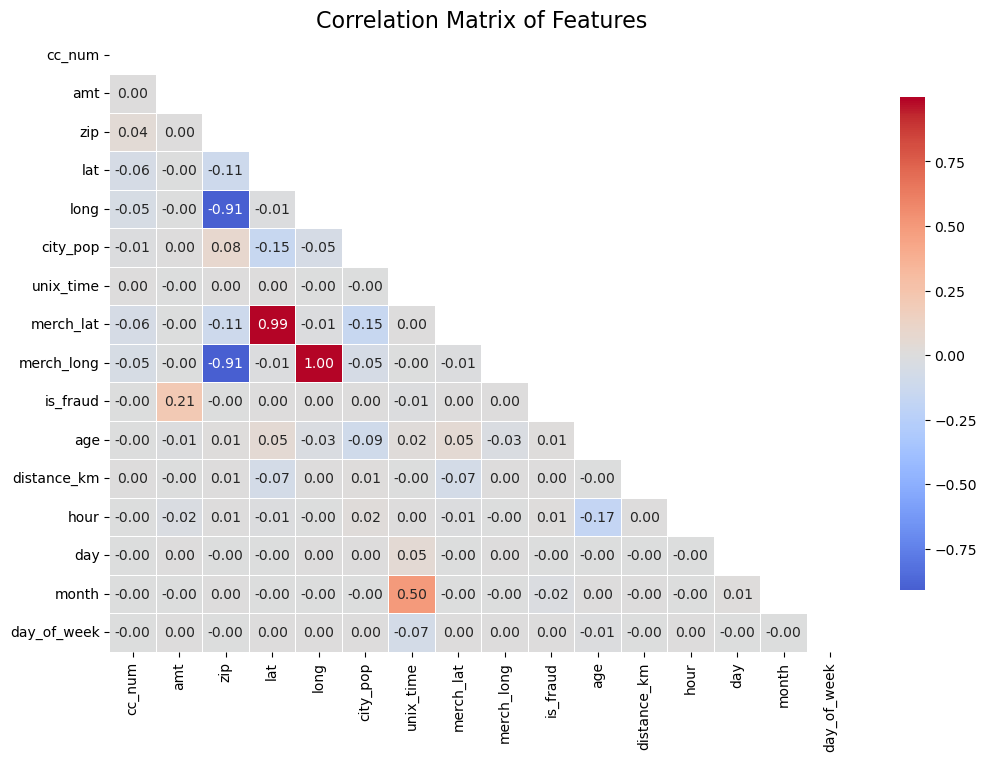

In [76]:
# Plot correlation matrix in heatmap
numeric_df = df_full.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))

# Use the numeric-only dataframe here
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,                
    annot=True,                
    fmt=".2f",                
    cmap='coolwarm',          
    center=0,                 
    linewidths=.5,            
    cbar_kws={"shrink": .8})

plt.title('Correlation Matrix of Features', fontsize=16)
plt.show()

***Observation***
The heatmap displays the colour to represent the strength and direction of relationships between variables. 
Dark Red/Bright Colours: Indicate a strong positive correlation (closer to +1.0)
Dark Blue/Dark Colours: Indicate a strong negative correlation (closer to -1.0)
Referring to the chart, there are two pairs of features that are nearly identical, such as lat & merch_lat, long & merch_long, zip & long, and zip & merch_long. Therefore, we can consider dropping one of each pair.

Moreover, there are corelation between the target class (is_fraud) and amt. It suggests that as the transaction amount increases, the likelihood of fraud increases.

***Key Insights***
We can use these results to drop redundant features and highlight important features. 

---

***Conclusion for Data Exploration***

The observations and insights from Exploratory Data Analysis (EDA) help the data analyst understand and capture patterns, trends, and relationships between features and the target class. By analysing the data alongside the specific nature of fraudulent transactions, we can better plan the development of the machine learning model. This process identifies which features have a strong relationship to the target and which are weak. Moreover, we notice that we have to address imbalanced data before training the model. Consequently, we can perform effective data preprocessing and prepare the data for model training in the next step.

<hr style="border: none; border-top: 5px double #333;">

# **4.Data Preprocessing**

## **4.1) Data assessment**

Data assessment involves examining data to determine its quality, highlighting factors such as consistent formatting and outliers, including
1. Exploring the Statistical Summary of the Data
2. Exploring how many rows and columns
3. Display the top 5 rows to understand what kind of information and ensure data quality.
   

In [82]:
# Explore Data Type of data both train and test set
df_train.info()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop               

In [83]:
# View how many rows and columns
print(f"Train Shape: {df_train.shape}")
print(f"Test Shape: {df_test.shape}")

Train Shape: (1296675, 22)
Test Shape: (555719, 22)


In [84]:
# View Numerical Summary
display(df_train.describe().T)
display(df_test.describe().T)

,count,mean,std,min,25%,50%,75%,max
cc_num,1296675.0,4.171920e+17,1.308806e+18,6.041621e+10,1.800429e+14,3.521417e+15,4.642255e+15,4.992346e+18
amt,1296675.0,7.035104e+01,1.603160e+02,1.000000e+00,9.650000e+00,4.752000e+01,8.314000e+01,2.894890e+04
zip,1296675.0,4.880067e+04,2.689322e+04,1.257000e+03,2.623700e+04,4.817400e+04,7.204200e+04,9.978300e+04
lat,1296675.0,3.853762e+01,5.075808e+00,2.002710e+01,3.462050e+01,3.935430e+01,4.194040e+01,6.669330e+01
long,1296675.0,-9.022634e+01,1.375908e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.015800e+01,-6.795030e+01
city_pop,1296675.0,8.882444e+04,3.019564e+05,2.300000e+01,7.430000e+02,2.456000e+03,2.032800e+04,2.906700e+06
unix_time,1296675.0,1.349244e+09,1.284128e+07,1.325376e+09,1.338751e+09,1.349250e+09,1.359385e+09,1.371817e+09
merch_lat,1296675.0,3.853734e+01,5.109788e+00,1.902779e+01,3.473357e+01,3.936568e+01,4.195716e+01,6.751027e+01
merch_long,1296675.0,-9.022646e+01,1.377109e+01,-1.666712e+02,-9.689728e+01,-8.743839e+01,-8.023680e+01,-6.695090e+01
is_fraud,1296675.0,5.788652e-03,7.586269e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


,count,mean,std,min,25%,50%,75%,max
cc_num,555719.0,4.178387e+17,1.309837e+18,6.041621e+10,1.800429e+14,3.521417e+15,4.635331e+15,4.992346e+18
amt,555719.0,6.939281e+01,1.567459e+02,1.000000e+00,9.630000e+00,4.729000e+01,8.301000e+01,2.276811e+04
zip,555719.0,4.884263e+04,2.685528e+04,1.257000e+03,2.629200e+04,4.817400e+04,7.201100e+04,9.992100e+04
lat,555719.0,3.854325e+01,5.061336e+00,2.002710e+01,3.466890e+01,3.937160e+01,4.189480e+01,6.568990e+01
long,555719.0,-9.023133e+01,1.372178e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.017520e+01,-6.795030e+01
city_pop,555719.0,8.822189e+04,3.003909e+05,2.300000e+01,7.410000e+02,2.408000e+03,1.968500e+04,2.906700e+06
unix_time,555719.0,1.380679e+09,5.201104e+06,1.371817e+09,1.376029e+09,1.380762e+09,1.385867e+09,1.388534e+09
merch_lat,555719.0,3.854280e+01,5.095829e+00,1.902742e+01,3.475530e+01,3.937659e+01,4.195416e+01,6.667930e+01
merch_long,555719.0,-9.023138e+01,1.373307e+01,-1.666716e+02,-9.690513e+01,-8.744520e+01,-8.026464e+01,-6.695203e+01
is_fraud,555719.0,3.859864e-03,6.200784e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


In [85]:
# View the first 5 rows to confirm train set is loaded correctly
df_train.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [86]:
# View the first 5 rows to confirm test set is loaded correctly
df_test.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


---

## **4.2) Data Cleaning**

After reviewing the data at the data assessment step, this session includes constructing the dataset, which is ready for the next process, 
including 
1. Handling missing values
2. Handling duplicate values

In [90]:
# Check missing values in the data set 
df_train.isnull().sum() # In this case, there is no missing value

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [91]:
# Check missing values in the data set 
df_test.isnull().sum()  # In this case, there is no missing value

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [92]:
# Check how many rows are duplicated at train set
print(f"Total duplicates: {df_train.duplicated().sum()}") # no duplicate row at test set

# View the duplication row
duplicate_rows = df_train[df_train.duplicated(keep=False)]
print(duplicate_rows.head())

Total duplicates: 0
Empty DataFrame
Columns: [trans_date_trans_time, cc_num, merchant, category, amt, first, last, gender, street, city, state, zip, lat, long, city_pop, job, dob, trans_num, unix_time, merch_lat, merch_long, is_fraud]
Index: []

[0 rows x 22 columns]


In [93]:
# Check how many rows are duplicated at test set
print(f"Total duplicates: {df_test.duplicated().sum()}") # no duplicate row at test set

# View the duplication row
duplicate_rows = df_test[df_test.duplicated(keep=False)] 
print(duplicate_rows.head())

Total duplicates: 0
Empty DataFrame
Columns: [trans_date_trans_time, cc_num, merchant, category, amt, first, last, gender, street, city, state, zip, lat, long, city_pop, job, dob, trans_num, unix_time, merch_lat, merch_long, is_fraud]
Index: []

[0 rows x 22 columns]


## **4.3) Data Transformation**

This session, I start working on optimizing the format of data. Methods, including
1. Extract hour, day, month, and day of week from transaction date and time
2. Calculate customer age from date of birth
3. Calculate the distance between the customer's location and the merchant's location by using the Haversine formula
4. Convert Continuous to Categorical
5. Label encoding for Categorical

In [96]:
# DateTime Extraction
def datetime_extraction(df):
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])   #  Converting to Datetime Objects
    df['hour'] = df['trans_date_trans_time'].dt.hour                            #  Extracting DateTime to hour
    df['day'] = df['trans_date_trans_time'].dt.day                              #  Extracting DateTime to day
    df['month'] = df['trans_date_trans_time'].dt.month                          #  Extracting DateTime to month
    df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek                #  Extracting DateTime to day of week
    return df

df_train = datetime_extraction(df_train)
df_test =  datetime_extraction(df_test)

In [97]:
# Customer Age Extraction
def age_extraction(df):
    df['dob'] = pd.to_datetime(df['dob'])
    df['age'] = df['trans_date_trans_time'].dt.year - df['dob'].dt.year    
    return df

df_train = age_extraction(df_train)
df_test = age_extraction(df_test)

In [98]:
# Distant Extraction by using Haversine Formula to calculate the distance between two locations
def calculate_haversine(df):
    # Transform Degrees to Radians
    lat1, lon1 = np.radians(df['lat']), np.radians(df['long'])
    lat2, lon2 = np.radians(df['merch_lat']), np.radians(df['merch_long'])

    # The differences between 2 points
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    # Calculate the square of half the chord length
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2

    #Calculate Angular distance
    c = 2 * np.arcsin(np.sqrt(a))

    # Calculate the distance (Km.)
    r = 6371 #Earth radius
    return c * r

# Driver code
df_train['distance_km'] = calculate_haversine(df_train)
df_test['distance_km'] = calculate_haversine(df_test)

In [99]:
# Copy dataset for CatBoost because this model does not require encoding in the next step of data prpcessing.
df_train_cat = df_train.copy()
df_test_cat = df_test.copy()

Numerical to Categorical (Group Binning)
>Variables: `'age'`, `'hour'`
   I selected 'age' and 'hour' to perform width binning because discrete bins are easier to interpret for                                                  business logic. Because it can identify the high-risk segment such as specific age and specific time.

In [101]:
# Numerical to Categorical (Group Binning) for 'age'. Then, convert to numeric codes (Label Encoding)
# Define the processing function
def preprocess_age(df):
    # Define thresholds and labels
    # Bins: 0-25 (Gen Z), 26-40 (Millennials), 41-60 (Gen X), 61-110 (Boomers)
    bins = [0, 25, 40, 60, 110]
    labels = ['Gen Z', 'Millennials', 'Gen X', 'Boomers']
    
    # Apply binning
    df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)
    
    # Convert to numeric codes for Random Forest (Label Encoding)
    # .cat.codes assigns integers based on the order of the 'labels' list
    df['age_group_encoded'] = df['age_group'].cat.codes
    
    return df

# Apply to datasets
df_train = preprocess_age(df_train)
df_test = preprocess_age(df_test)


In [102]:
# Numerical to Categorical (Group Binning) for '้hour'. Then, convert to numeric codes (Label Encoding)
# Define the processing function
def preprocess_time_features(df):
    # Bins: 0-6 (Late Night), 7-11 (Morning), 12-17 (Afternoon), 18-23 (Evening)
    hour_bins = [0, 7, 12, 18, 24]
    hour_labels = ['Late Night', 'Morning', 'Afternoon', 'Evening']
    
    # Apply binning (right=False means 7 goes into Morning, not Late Night)
    df['hour_group'] = pd.cut(df['hour'], bins=hour_bins, labels=hour_labels, right=False)
    
    # Label Encoding (Late Night=0, Morning=1, Afternoon=2, Evening=3)
    df['hour_group'] = pd.Categorical(df['hour_group'], categories=hour_labels, ordered=True)
    df['hour_group_encoded'] = df['hour_group'].cat.codes
    
    return df

# Apply to datasets
df_train = preprocess_time_features(df_train)
df_test = preprocess_time_features(df_test)

Label encoding for Categorical 
>Variables: `'gender'`, `'category'`
   I selected 'gender' and 'category' to perform Label encoding.


In [104]:
# Label encoding 
le = LabelEncoder()

# for Categorical('gender') 
df_train['gender_encoded'] = le.fit_transform(df_train['gender'])
df_test['gender_encoded'] = df_test['gender'].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

# for Categorical ('category') 
df_train['category_encoded'] = le.fit_transform(df_train['category'])
df_test['category_encoded'] = df_test['category'].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

## **4.4) Data Reduction**

After complete data transformation, this session presents data reduction to improve the efficiency of analysis by organising your data into a smaller including. 
 1. Dropping Columns that are Unique Identifiers or High Cardinality
 2. Removing unnecessary data that isn’t relevant to the analysis
 3. Dropping columns after Feature Extraction

In [107]:
# View data summary
df_train.info()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 34 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[ns]
 1   cc_num                 1296675 non-null  int64         
 2   merchant               1296675 non-null  object        
 3   category               1296675 non-null  object        
 4   amt                    1296675 non-null  float64       
 5   first                  1296675 non-null  object        
 6   last                   1296675 non-null  object        
 7   gender                 1296675 non-null  object        
 8   street                 1296675 non-null  object        
 9   city                   1296675 non-null  object        
 10  state                  1296675 non-null  object        
 11  zip                    1296675 non-null  int64         
 12  lat                    1296675 no

In [108]:
# Dropping Columns that are Unique Identifiers or High Cardinality, to prevent overfitting and to ensure the model learns generalizable patterns rather than memorising individual data points
# consisting of 'cc_num', 'first', 'last', 'street','zip'and 'trans_num'

# Dropping columns after Feature Extraction
# consisting of merch_lat, merch_long, lat, long, DOB, transaction date and time, and unix_time

cols_to_drop = ['cc_num', 'merchant', 'first', 'last', 'street', 'city', 'state', 'zip', 'job', 'trans_num', 'unix_time','lat', 'long', 'merch_lat', 'merch_long', 'dob', 'trans_date_trans_time', 'age', 'age_group', 'hour', 'hour_group', 'gender', 'category']

df_train = df_train.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)

print(f"Train Shape: {df_train.shape}")
print(f"Test Shape: {df_test.shape}")

Train Shape: (1296675, 11)
Test Shape: (555719, 11)


In [109]:
# View data summary
df_train.info()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   amt                 1296675 non-null  float64
 1   city_pop            1296675 non-null  int64  
 2   is_fraud            1296675 non-null  int64  
 3   day                 1296675 non-null  int32  
 4   month               1296675 non-null  int32  
 5   day_of_week         1296675 non-null  int32  
 6   distance_km         1296675 non-null  float64
 7   age_group_encoded   1296675 non-null  int8   
 8   hour_group_encoded  1296675 non-null  int8   
 9   gender_encoded      1296675 non-null  int32  
 10  category_encoded    1296675 non-null  int32  
dtypes: float64(2), int32(5), int64(2), int8(2)
memory usage: 76.7 MB
<class 'pandas.core.frame.DataFrame'>
Index: 555719 entries, 0 to 555718
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---

In [110]:
# Referring to the dataset for catboost, I drop columns after Feature Extraction

cols_to_drop_cat = ['cc_num', 'merchant', 'first', 'last', 'street', 'city', 'state', 'zip', 'job', 'trans_num', 'unix_time','lat', 'long', 'merch_lat', 'merch_long', 'dob', 'trans_date_trans_time']

df_train_cat = df_train_cat.drop(columns=cols_to_drop_cat)
df_test_cat = df_test_cat.drop(columns=cols_to_drop_cat)

print(f"Train Shape: {df_train_cat.shape}")
print(f"Test Shape: {df_test_cat.shape}")

Train Shape: (1296675, 11)
Test Shape: (555719, 11)


## **4.5) Split data set**

Training, validation, and test sets are partitioned data used to build, tune, and evaluate machine learning models, respectively. 
According to the dataset from Kaggle, include training set of 1,296,675 records and a test set with 555,719 records. Therefore, I chose to split the test set as a validation set of 185,239 records and the remaining test set of 370,480 records for the proportion of training, validation and test set at 70%, 10%, and 20%, respectively.

In [113]:
# Split Validation and test set (for Random forest and XGBoost)
df_val, df_test = train_test_split(
    df_test, 
    test_size=0.66,       
    random_state=42, 
    stratify=df_test['is_fraud']  
)

print("--- Training Set ---")
print(f"Shape: {df_train.shape}")
print(f"Class Ratio:\n{df_train['is_fraud'].value_counts(normalize=True)}")

print("\n--- Validation Set ---")
print(f"Shape: {df_val.shape}")
print(f"Class Ratio:\n{df_val['is_fraud'].value_counts(normalize=True)}")

print("\n--- Test Set ---")
print(f"Shape: {df_test.shape}")
print(f"Class Ratio:\n{df_test['is_fraud'].value_counts(normalize=True)}")

--- Training Set ---
Shape: (1296675, 11)
Class Ratio:
is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64

--- Validation Set ---
Shape: (188944, 11)
Class Ratio:
is_fraud
0    0.996142
1    0.003858
Name: proportion, dtype: float64

--- Test Set ---
Shape: (366775, 11)
Class Ratio:
is_fraud
0    0.996139
1    0.003861
Name: proportion, dtype: float64


In [114]:
# Split the dataset into Features and the Target Variable (for Random forest and XGBoost)
# Training Set
X_train = df_train.drop('is_fraud', axis=1)
y_train = df_train['is_fraud']

# Validation Set
X_val = df_val.drop('is_fraud', axis=1)
y_val = df_val['is_fraud']

# Test Set
X_test = df_test.drop('is_fraud', axis=1)
y_test = df_test['is_fraud']

In [115]:
# Split Validation and test set (for CatBoost)
df_val_cat, df_test_cat = train_test_split(
    df_test_cat, 
    test_size=0.66,       
    random_state=42, 
    stratify=df_test_cat['is_fraud']  
)

print("--- Training Set ---")
print(f"Shape: {df_train_cat.shape}")
print(f"Class Ratio:\n{df_train_cat['is_fraud'].value_counts(normalize=True)}")

print("\n--- Validation Set ---")
print(f"Shape: {df_val_cat.shape}")
print(f"Class Ratio:\n{df_val_cat['is_fraud'].value_counts(normalize=True)}")

print("\n--- Test Set ---")
print(f"Shape: {df_test_cat.shape}")
print(f"Class Ratio:\n{df_test_cat['is_fraud'].value_counts(normalize=True)}")

--- Training Set ---
Shape: (1296675, 11)
Class Ratio:
is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64

--- Validation Set ---
Shape: (188944, 11)
Class Ratio:
is_fraud
0    0.996142
1    0.003858
Name: proportion, dtype: float64

--- Test Set ---
Shape: (366775, 11)
Class Ratio:
is_fraud
0    0.996139
1    0.003861
Name: proportion, dtype: float64


In [116]:
# Split the dataset into Features and the Target Variable (for CatBoost)
# Training Set
X_train_cat = df_train_cat.drop('is_fraud', axis=1)
y_train_cat = df_train_cat['is_fraud']

# Validation Set
X_val_cat = df_val_cat.drop('is_fraud', axis=1)
y_val_cat = df_val_cat['is_fraud']

# Test Set
X_test_cat = df_test_cat.drop('is_fraud', axis=1)
y_test_cat = df_test_cat['is_fraud']

<hr style="border: none; border-top: 5px double #333;">

# **5.Model Training**

## **5.1) Random Forest (Baseline)**

A random forest is an ensemble of decision trees, where each tree is trained on a random subset of data and features. The final prediction is made by aggregating (voting or averaging) the results from all trees. It is advantageous to reduce overfitting with high accuracy and also provide feature importance scores for model optimisation. 

In [121]:
# Define model: Random Forest
rfc_baseline =  RandomForestClassifier(
        n_estimators=100,                       # forest will consist of 100 individual decision trees as baseline
        criterion='gini',                       # standard for classification
        random_state=42,                        # Reproducibility
        n_jobs=-1,                              # Random Forest builds multiple trees independently, lead to train faster
        verbose=False)                          # Clean Workspace to prevent the model from printing out progress logs while training        


In [122]:
# Fit the model on train data and predict on validation data 
start_time = time.time()
rfc_baseline.fit(X_train, y_train)
train_time = time.time() - start_time

In [123]:
# Predict and Evaluation
y_predicted = rfc_baseline.predict(X_val)

print('Classification report:\n', classification_report(y_val, y_predicted))
print('Confusion matrix:\n',confusion_matrix(y_true = y_val, y_pred = y_predicted))
print("Accuracy: ",accuracy_score(y_val,y_predicted))
print('ROC AUC : ', roc_auc_score(y_val, y_predicted))
print('Average Precision : ', average_precision_score(y_val, y_predicted))
print(f"Training time: {train_time:.4f} seconds")

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    188215
           1       0.94      0.66      0.78       729

    accuracy                           1.00    188944
   macro avg       0.97      0.83      0.89    188944
weighted avg       1.00      1.00      1.00    188944

Confusion matrix:
 [[188183     32]
 [   246    483]]
Accuracy:  0.9985286645778644
ROC AUC :  0.8311907109995584
Average Precision :  0.6226851685646141
Training time: 55.7773 seconds


---

## **5.2) Random Forest (Optimised)**

After training the model, I get the prediction on the model baseline. Then, I improve model performance by 

1. Feature Important and
2. Stratified K-Fold and Hyperparameter Tuning




**Feature Important**

Feature Importance in Random Forests measures how much each feature contributes to the model’s prediction accuracy. It helps in identifying the most influential input variables, improving performance, interpretability and computational efficiency


In [128]:
# Convert dictionary to sorted arrays 
feature_importance = rfc_baseline.feature_importances_
feature_names = X_train.columns

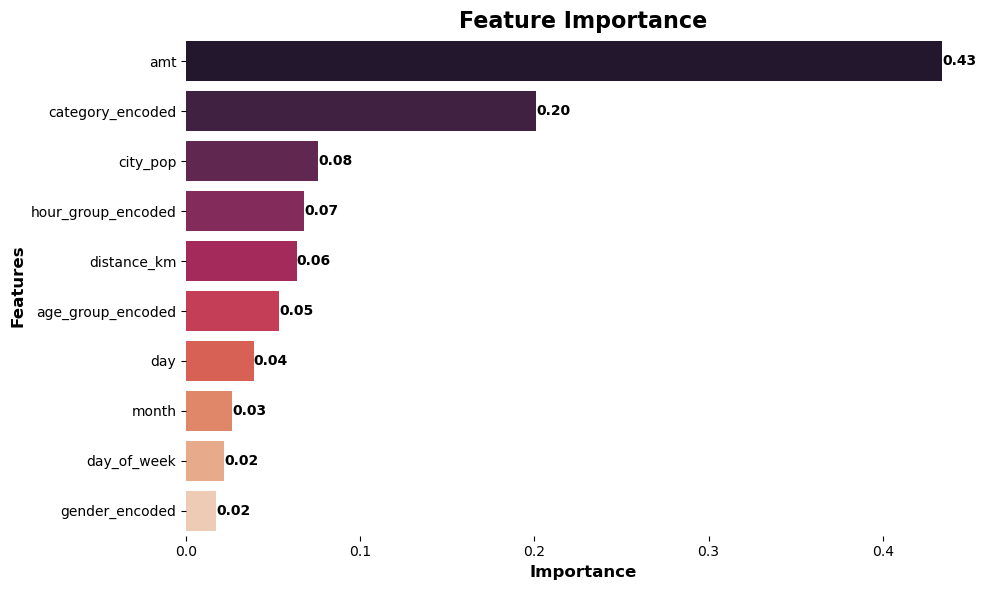

In [129]:
# Sort values and names in descending order
sorted_idx = np.argsort(feature_importance)[::-1]
feature_importance = np.array(feature_importance)[sorted_idx]
feature_names = np.array(feature_names)[sorted_idx]

# Create a more creative plot using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance, y=feature_names, hue=feature_names, palette='rocket', legend=False)

plt.title('Feature Importance', fontweight='bold', fontsize=16)
plt.xlabel('Importance', fontweight='bold', fontsize=12)
plt.ylabel('Features', fontweight='bold', fontsize=12)

# Add data labels
for i, value in enumerate(feature_importance):
    plt.text(value, i, f'{value:.2f}', fontweight='bold', fontsize=10, va='center')

# Improve aesthetics
sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.show()

My model found that the Transaction Amount and Category of Merchant were the top predictors of fraud. This aligns with real-world financial patterns where high-value, specific-merchant-type transactions are higher risk. This visualization confirms that the model heavily prioritizes 'Amount' and 'Category' as the primary drivers of risk. This provides transparency to the Fraud Investigation team on why certain transactions are being flagged.

---

**Stratified K-Fold and Hyperparameter Tuning**

I use Random Search as the method, which searches the hyperparameter space randomly for the best performance. This makes it fast and less computationally expensive.

For hyperparameter tunning, RandomizedSearchCV is a machine-learning technique used to optimize a model's hyperparameters by performing a random search over a specified parameter grid. I started from

   - Define Model: Choose the machine learning algorithm you want to optimize
   - Create the Parameter Grid: Specify the parameters and the range of values you want to search over.
   - Instantiate RandomizedSearchCV: Provide the model, parameter grid, and other settings like the number of iterations, cross-       validation strategy, etc.
   - Fit the Model: Run the random search on the training data.
   - Evaluate the Best Model: Check the performance of the best-found parameters.

The parameters of the estimator used to apply these methods are optimized by Stratified K-Fold cross-validated search over parameter settings. In real-world classification tasks, the distribution of the fraud dataset is often imbalanced. If we randomly split this data, there may be some training/test sets that have very few samples or even no samples for the minority class. Stratified K-Fold Cross Validation is a technique used for evaluating a model and is useful for imbalanced data. It ensures that both training and test sets provide an accurate representation of the full dataset's class proportions and better generalisation in the evaluation set.

Moreover, Imbalanced datasets are one of the most common challenges in machine learning for fraud detection analysis. The vast majority of one class over others, resulting in the model bias to the majority class, and subpar performance on the minority class. To tackle class imbalance, 'class_weight' is a hyperparameter used to address class imbalance by assigning different levels of importance to each class during training. It helps the model avoid bias toward the majority class and improves performance on minority classes.

In [133]:
# Create the Parameter Grid
params = { 
    'n_estimators': [100, 200, 400],       # the number of individual decision trees in the Random Forest, more trees make the model more robust and prevent overfitting, but they also make training slower and require more memory         
    'max_features': ['sqrt', 'log2', None], # This controls how many features (columns) each individual tree is allowed to look at when searching for the best split at a node     
    'class_weight': ['balanced', 'balanced_subsample', None, {0: 1, 1: 5}]       # to automatically adjust weights based on the bootstrap sample for every tree grown.
}

In [134]:
# Define Cross-Validation (CV) strategy
cross_val = StratifiedKFold(n_splits=5) # The model will be trained and tested during the tuning phase 5 times.

In [135]:
# Instantiate RandomizedSearchCV
clf_random = RandomizedSearchCV(
    estimator=rfc_baseline,        # the model that I want to tune
    param_distributions=params,    # Parameter Grid
    n_iter=20,                     # The number of different parameter combinations
    cv=cross_val,                  # StratifiedKFold Cross-Validation
    verbose=False,                 # Detailed logs
    random_state=42,               # Reproducibility
    n_jobs=-1,                     # all available CPU cores to run the search in parallel.
    scoring='average_precision'    # I highlight the performance of average precision. Because it is the best balance between catching frauds (Recall) and not accusing innocent people (Precision).
)

In [136]:
# Fit the Model
# clf_random.fit(X_train, y_train)

In [137]:
# Evaluate the Best Model
# print("Best Score (Average Precision):", clf_random.best_score_)
# print("Best Params:", clf_random.best_params_)

In [138]:
# Passing the best parameteres based on Randomized Search CV
rfc_optimised = RandomForestClassifier(
        n_estimators=100,        
        max_features= None,        
        criterion='gini',                       # standard for classification
        random_state=42,                        # Reproducibility
        n_jobs=-1,                           
        verbose=False,                          # Clean Workspace to prevent the model from printing out progress logs while training
        class_weight={0: 1, 1: 5},              # to automatically adjust weights based on the bootstrap sample for every tree grown.
        bootstrap=True    
)

In [139]:
# Fitting the model on Train data and Predicting on Validation Data
start_time = time.time()
rfc_optimised.fit(X_train,y_train)
train_time = time.time() - start_time

In [140]:
# Prediction and Evaluation Metrics
y_predicted = rfc_optimised.predict(X_val)

print('Classification report:\n', classification_report(y_val, y_predicted))
print('Confusion matrix:\n',confusion_matrix(y_true = y_val, y_pred = y_predicted))
print("Accuracy: ",accuracy_score(y_val,y_predicted))
print('ROC AUC : ', roc_auc_score(y_val, y_predicted))
print('Average Precision : ', average_precision_score(y_val, y_predicted))
print(f"Training time: {train_time:.4f} seconds")

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    188215
           1       0.91      0.70      0.79       729

    accuracy                           1.00    188944
   macro avg       0.95      0.85      0.89    188944
weighted avg       1.00      1.00      1.00    188944

Confusion matrix:
 [[188164     51]
 [   221    508]]
Accuracy:  0.9985604200186299
ROC AUC :  0.8482870132138454
Average Precision :  0.6344384539330296
Training time: 136.6959 seconds


---

## **5.3) XGBoost (Baseline)**

XGBoost is a gradient boosting algorithm, which is designed to be highly efficient, flexible and portable.  It is an optimized gradient boosting algorithm that combines multiple weak models into a stronger, high-performance model by using decision trees as base learners, building them sequentially so each tree corrects errors from the previous one and it is known as boosting. Moreover, It features parallel processing for faster training on large datasets and allows parameter customisation to optimize performance for specific problems.

In [144]:
# Define Model: XGBoost
xgb_baseline = XGBClassifier(
        n_estimators=100,                       # forest will consist of 100 individual decision trees as baseline
        random_state=42,                        # Reproducibility
        n_jobs=-1)                                 

In [145]:
# Fit the model on train data and predict on validation data 
start_time = time.time()
xgb_baseline.fit(X_train, y_train)
train_time = time.time() - start_time

In [146]:
# Predict and Evaluation
y_predicted = xgb_baseline.predict(X_val)

print('Classification report:\n', classification_report(y_val, y_predicted))
print('Confusion matrix:\n',confusion_matrix(y_true = y_val, y_pred = y_predicted))
print("Accuracy: ",accuracy_score(y_val,y_predicted))
print('ROC AUC : ', roc_auc_score(y_val, y_predicted))
print('Average Precision : ', average_precision_score(y_val, y_predicted))
print(f"Training time: {train_time:.4f} seconds")

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    188215
           1       0.82      0.63      0.72       729

    accuracy                           1.00    188944
   macro avg       0.91      0.82      0.86    188944
weighted avg       1.00      1.00      1.00    188944

Confusion matrix:
 [[188114    101]
 [   267    462]]
Accuracy:  0.9980523329663816
ROC AUC :  0.8166041178063481
Average Precision :  0.521466622365913
Training time: 4.2995 seconds


---

## **5.4) XGBoost (Optimised)**

After training the model, I get the prediction on the model baseline. Then, I improve model performance by 

1. Feature Important and
2. Stratified K-Fold and Hyperparameter Tuning


**Feature Important**

Feature Importance in XGBoost refers to the scores assigned to input features based on their contribution to the model’s predictions. In other words, it quantifies how much each feature influences the model’s decision-making process. Features with higher importance scores are considered more influential in determining the output, while features with lower scores have less impact.

In [151]:
#  Calculate Feature Importance
importance_dict = xgb_baseline.get_booster().get_score(importance_type='gain')

# Convert dictionary to sorted arrays 
feature_names = np.array(list(importance_dict.keys()))
feature_importance = np.array(list(importance_dict.values()))

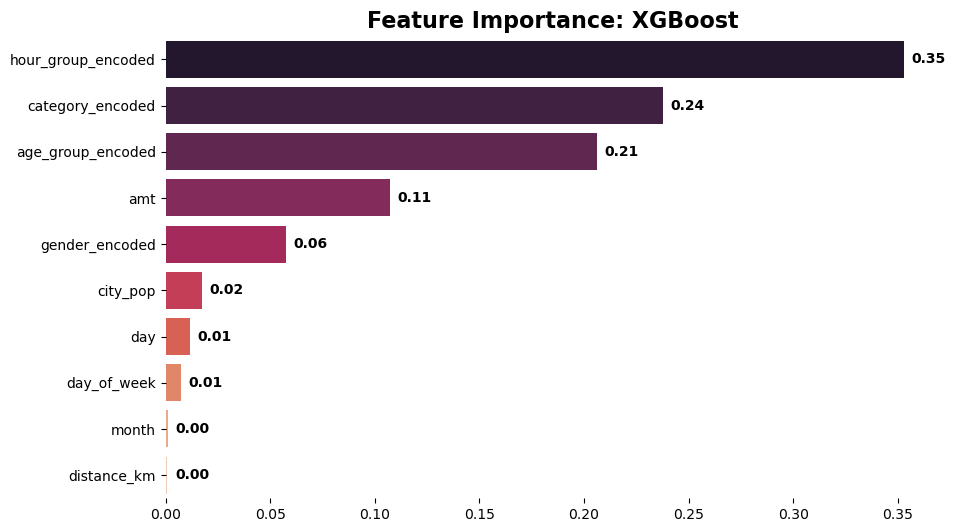

In [152]:
sorted_idx = np.argsort(xgb_baseline.feature_importances_)[::-1]
feat_imp = xgb_baseline.feature_importances_[sorted_idx]
feat_names = np.array(X_train.columns)[sorted_idx]


plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp, y=feat_names, hue=feat_names, palette='rocket', legend=False)
plt.title('Feature Importance: XGBoost', fontweight='bold', fontsize=16)
for i, v in enumerate(feat_imp):
    plt.text(v + (max(feat_imp) * 0.01), i, f'{v:.2f}', va='center', fontweight='bold')
sns.despine(left=True, bottom=True)
plt.show()

The model found that the top features of the XGBoost model are 'hour_group_encoded ' and 'category_encoded' These align with real-world financial patterns where specific time and category are higher risk. When, we compare with the feature important of random forest, the models highlight 'category_encoded', but the ranking of feature importance differs. In the random forest model, feature importance is based on the Gini index, while in the XGBoost model, it is calculated using gain. Random Forest builds trees independently. It favours numerical features with many possible split points. This is why 'amt' is the most important feature of random forest. While, XGBoost builds trees sequentially and highlights about fixing mistakes from the previous tree. 

---

**Stratified K-Fold and Hyperparameter Tuning**

For hyperparameter tunning, I used RandomizedSearchCV and  Stratified K-Fold cross-validated to optimize a model's hyperparameters by performing a random search over a specified parameter grid. 

Moreover, I used 'scale_pos_weight'as a hyperparameter used to address class imbalance by assigning different levels of importance to each class during training. It helps the model avoid bias toward the majority class and improves performance on minority classes

In [156]:
# Create the Parameter Grid
params = {
         'n_estimators' : [500, 1000, 1500, 2000],   # Number of boosting rounds. Higher values allow the model to learn
         'learning_rate': [0.1, 0.05, 0.01, 0.005],  # Step size shrinkage used in update to prevents overfitting.       
         'scale_pos_weight': [4, 5, 6, 7],           # Balances the positive (fraud) and negative (legit) weights.
         'max_depth' : [5, 7, 12],                   # Increasing this value makes the model more complex
         'min_child_weight' : [1, 3, 5],             # Used to control over-fitting
         'gamma': [1, 2],                            # Minimum loss reduction required to make a further partition on a leaf node. the larger gamma is, the more conservative the algorithm
         'reg_alpha' : [0.5, 0.6],                   # regularization to stop "guessing" on noise
         'reg_lambda' : [0.5, 1.0, 2.0],             # regularization to keep weights stable
         'subsample' : [0.5, 0.8],                   # Adds row randomness
         'colsample_bytree' : [0.5, 0.8]             # Adds feature randomness
}

In [157]:
# Define Cross-Validation (CV) strategy
cross_val = StratifiedKFold(n_splits=5) # The model will be trained and tested during the tuning phase 5 times.

In [158]:
# Instantiate RandomizedSearchCV
xgb_random = RandomizedSearchCV(
    estimator=xgb_baseline,        
    param_distributions=params, 
    n_iter=20, 
    cv=cross_val,
    verbose=False, 
    random_state=42, 
    n_jobs=-1,
    scoring='average_precision'
)

In [159]:
# xgb_random.fit(X_train, y_train)

In [160]:
# Evaluate the Best Model
# print("Best Score (Average Precision):", xgb_random.best_score_)
# print("Best Params:", xgb_random.best_params_)

In [161]:
# Passing the best parameteres based on Randomized Search CV
xgb_optimised = XGBClassifier(
    n_estimators=2000,        
    learning_rate=0.005,         
    random_state=42,             
    n_jobs=-1,
    scale_pos_weight=6,          
    max_depth=12,                
    min_child_weight=1,          
    gamma=2,                     
    reg_alpha=0.5,              
    reg_lambda=2.0,              
    subsample=0.8,              
    colsample_bytree=0.8
)

In [162]:
#Fit the model on train data and predict the model on validation data
start_time = time.time()
xgb_optimised.fit(X_train,y_train)
train_time = time.time() - start_time

In [163]:
# Prediction and Evaluation Metrices
y_predicted = xgb_optimised.predict(X_val)

print('Classification report:\n', classification_report(y_val, y_predicted))
print('Confusion matrix:\n',confusion_matrix(y_true = y_val, y_pred = y_predicted))
print("Accuracy: ",accuracy_score(y_val,y_predicted))
print('ROC AUC : ', roc_auc_score(y_val, y_predicted))
print('Average Precision : ', average_precision_score(y_val, y_predicted))
print(f"Training time: {train_time:.4f} seconds")

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    188215
           1       0.83      0.72      0.77       729

    accuracy                           1.00    188944
   macro avg       0.91      0.86      0.89    188944
weighted avg       1.00      1.00      1.00    188944

Confusion matrix:
 [[188106    109]
 [   202    527]]
Accuracy:  0.998354009653654
ROC AUC :  0.8611644841707782
Average Precision :  0.6000825670682729
Training time: 131.4580 seconds


---

## **5.5) CatBoost (Baseline)**

CatBoost is an advanced gradient-boosting library specifically designed to address the challenges of handling categorical data in machine learning. CatBoost is an open-source technology that has become quite popular quickly because it can produce high-performance models without requiring a lot of data preprocessing including missing value and encoding. 

In [167]:
# Instantiate Model: CatBoost
cat_baseline = CatBoostClassifier(
    iterations=100,     # The number of trees to build
    random_seed=42,
    verbose=False                    
)

# Define Categorical Feature
cat_features = ['category', 'gender']

In [168]:
# Fit the model on train data and predict on validation data 
start_time = time.time()
cat_baseline.fit(X_train_cat, y_train_cat, cat_features=cat_features)
train_time = time.time() - start_time

In [169]:
# Predict and Evaluation
y_predicted = cat_baseline.predict(X_val_cat)

print('Classification report:\n', classification_report(y_val_cat, y_predicted))
print('Confusion matrix:\n',confusion_matrix(y_true = y_val_cat, y_pred = y_predicted))
print("Accuracy: ",accuracy_score(y_val_cat,y_predicted))
print('ROC AUC : ', roc_auc_score(y_val_cat, y_predicted))
print('Average Precision : ', average_precision_score(y_val_cat, y_predicted))
print(f"Training time: {train_time:.4f} seconds")

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    188215
           1       0.88      0.75      0.81       729

    accuracy                           1.00    188944
   macro avg       0.94      0.88      0.91    188944
weighted avg       1.00      1.00      1.00    188944

Confusion matrix:
 [[188142     73]
 [   180    549]]
Accuracy:  0.9986609789143873
ROC AUC :  0.8763492827187714
Average Precision :  0.665654342394098
Training time: 18.9902 seconds


---

## **5.6) CatBoost (Optimised)**

After training the model, I get the prediction on the model baseline. Then, I improve model performance by 

1. Feature Important and
2. Stratified K-Fold and Hyperparameter Tuning

**Feature Important**

CatBoost provides robust feature importance methods to identify which input variables most influence model predictions. I use calculation type as PredictionValuesChange (Default) to shows how much the prediction changes, on average, when a feature value changes. It is fast to compute and often used for non-ranking objectives.

In [174]:
#  Calculate Feature Importance
feature_names = X_train_cat.columns
feature_importance = cat_baseline.get_feature_importance()

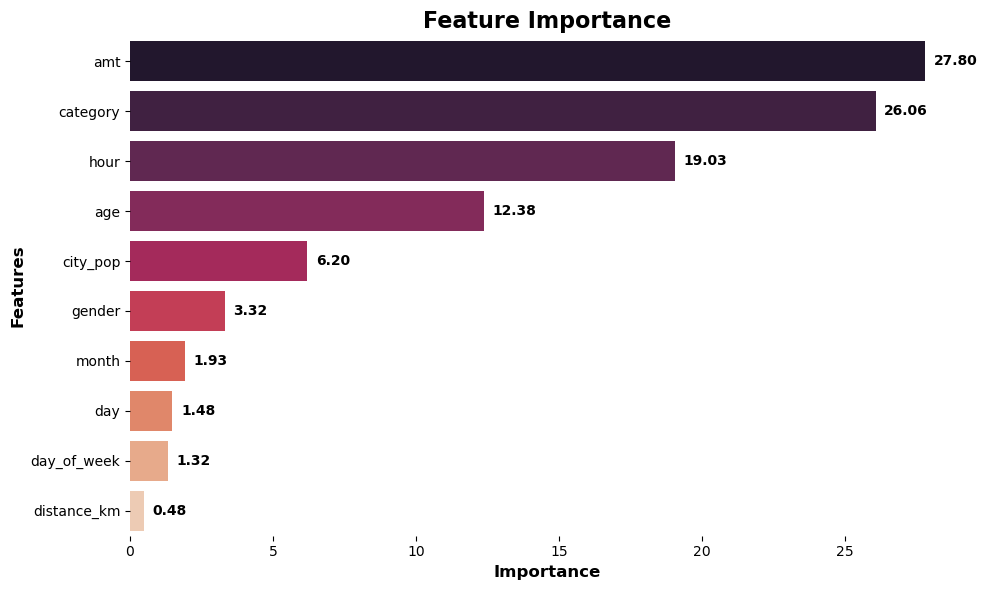

In [175]:
# Sort values and names in descending order
sorted_idx = np.argsort(feature_importance)[::-1]
feature_importance = np.array(feature_importance)[sorted_idx]
feature_names = np.array(feature_names)[sorted_idx]

# Create a more creative plot using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance, y=feature_names, hue=feature_names, palette='rocket', legend=False)

plt.title('Feature Importance', fontweight='bold', fontsize=16)
plt.xlabel('Importance', fontweight='bold', fontsize=12)
plt.ylabel('Features', fontweight='bold', fontsize=12)

# Add data labels
for i, value in enumerate(feature_importance):
    plt.text(value + 0.3, i, f'{value:.2f}', fontweight='bold', fontsize=10, va='center')

# Improve aesthetics
sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.show()

The model found that the top features of the CatBoost model are 'amt' and 'category' These align with the insight in part of data exploration and model of reandom forest and XGBoost. 

---

**Stratified K-Fold and Hyperparameter Tuning**

For hyperparameter tunning, I used RandomizedSearchCV and  Stratified K-Fold cross-validated to optimize a model's hyperparameters by performing a random search over a specified parameter grid. 

Moreover, I used 'scale_pos_weight'as a hyperparameter used to address class imbalance by assigning different levels of importance to each class during training. It helps the model avoid bias toward the majority class and improves performance on minority classes.

In [179]:
# Refined Parameter Grid 
params = {
    'iterations': [200, 300],           # The number of trees to build
    'learning_rate': [0.01, 0.1],   # Controls how fast the model learns. Smaller values (0.01) require more iterations but usually lead to better generalization
    'depth': [6, 10],                  # Depth of the trees. CatBoost uses symmetric trees
    'scale_pos_weight': [2, 5, 7]        # High priority: Forces model to care more about fraud
}

In [180]:
# Define Cross-Validation (CV) strategy
cross_val = StratifiedKFold(n_splits=5) # The model will be trained and tested during the tuning phase 5 times.

In [181]:
# Instantiate RandomizedSearchCV
cat_random = RandomizedSearchCV(
    estimator=cat_baseline,
    param_distributions=params,
    n_iter=20,
    cv=cross_val,
    scoring='average_precision',         
    n_jobs=1,              
    verbose=False
)

In [182]:
# Fit the Model
# cat_random.fit(X_train_cat, y_train_cat, cat_features=cat_features)

In [183]:
# Evaluate the Best Model
# print("Best Score (Average Precision):", cat_random.best_score_)
# print("Best Params:", cat_random.best_params_)

In [184]:
# Passing the best parameteres based on Randomized Search CV 
cat_optimised = CatBoostClassifier(
    cat_features=cat_features, 
    random_seed=42,
    iterations= 200,
    learning_rate=0.1,
    depth = 10,
    scale_pos_weight = 2
)

In [185]:
#Fit the model on train data and predict the model on validation data
start_time = time.time()
cat_optimised.fit(X_train_cat,y_train_cat, cat_features=cat_features)
train_time = time.time() - start_time

0:	learn: 0.4550928	total: 428ms	remaining: 1m 25s
1:	learn: 0.2674228	total: 1.23s	remaining: 2m 1s
2:	learn: 0.1657616	total: 1.85s	remaining: 2m 1s
3:	learn: 0.0997557	total: 2.46s	remaining: 2m
4:	learn: 0.0654671	total: 3s	remaining: 1m 57s
5:	learn: 0.0464441	total: 3.57s	remaining: 1m 55s
6:	learn: 0.0337240	total: 4.08s	remaining: 1m 52s
7:	learn: 0.0268060	total: 4.58s	remaining: 1m 50s
8:	learn: 0.0222808	total: 5.33s	remaining: 1m 53s
9:	learn: 0.0199232	total: 5.89s	remaining: 1m 51s
10:	learn: 0.0175845	total: 6.43s	remaining: 1m 50s
11:	learn: 0.0162797	total: 6.95s	remaining: 1m 48s
12:	learn: 0.0146443	total: 7.46s	remaining: 1m 47s
13:	learn: 0.0138120	total: 8.04s	remaining: 1m 46s
14:	learn: 0.0133952	total: 8.56s	remaining: 1m 45s
15:	learn: 0.0126598	total: 9.08s	remaining: 1m 44s
16:	learn: 0.0122554	total: 9.59s	remaining: 1m 43s
17:	learn: 0.0119079	total: 10.1s	remaining: 1m 42s
18:	learn: 0.0114747	total: 10.6s	remaining: 1m 41s
19:	learn: 0.0111008	total: 11.

In [186]:
# Prediction and Evaluation Metrices
y_predicted = cat_optimised.predict(X_val_cat)

print('Classification report:\n', classification_report(y_val_cat, y_predicted))
print('Confusion matrix:\n',confusion_matrix(y_true = y_val_cat, y_pred = y_predicted))
print("Accuracy: ",accuracy_score(y_val_cat,y_predicted))
print('ROC AUC : ', roc_auc_score(y_val_cat, y_predicted))
print('Average Precision : ', average_precision_score(y_val_cat, y_predicted))
print(f"Training time: {train_time:.4f} seconds")

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    188215
           1       0.91      0.79      0.84       729

    accuracy                           1.00    188944
   macro avg       0.95      0.89      0.92    188944
weighted avg       1.00      1.00      1.00    188944

Confusion matrix:
 [[188155     60]
 [   154    575]]
Accuracy:  0.9988673892793632
ROC AUC :  0.8942164651543504
Average Precision :  0.7150390499187191
Training time: 114.4013 seconds


<hr style="border: none; border-top: 5px double #333;">

# **6. Model Evaluation**

## **6.1) Model Performance Comparison**

The results present precision, recall, F1 score, accuracy  in classification report can be computed from the confusion matrix. The confusion matrix display the relationship between predicted and actual values. “TN” refers to True Negative, and “TP” refers to True Positive. These values represent the number of negative or positive instances that are correctly classified. On the other hand, “FN” refers to False Negative, and “FP” refers to False Positive. These values represent the number of negative or positive instances that are incorrectly classified.
<center>
    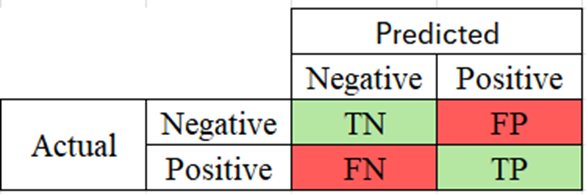
</center>


This matrix can be used to compute performance metrics as follows.
1. **Recall** measures the model’s ability to correctly identify all positive instances. The formula for calculating can be shown as below:
   $$Recall = \frac{TP}{TP + FN}$$
   
2. **Precision** measures the proportion of correctly predicted positive instances among all instances that are predicted as positive. The formula for calculating can be shown as below:
   $$Precision = \frac{TP}{TP + FP}$$

3. **F1 score** is the harmonic mean of precision and recall. The formula for calculating can be shown as below:
   $$F1\ Score = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$
   
4. **Accuracy** measures the overall correctness of the model by calculating the proportion of total correct predictions among all predictions. The formula for calculating can be shown as below:
   $$Accuracy = \frac{TP + TN}{TP + FN + FP + TN}$$


***When dealing with imbalanced data in fraud scenario, accuracy are not suitable***, as they can be skewed by the majority class, giving a false sense of high performance even when the minority class is poorly predicted. Therefore, we consider Recall, Precision, and F1 Score

5. **PR-AUC**
  I consider PR-AUC to evaluate model performance PR-AUC (Area Under the Precision-Recall Curve) is a performance metric used in machine learning to evaluate binary classification models, particularly when dealing with highly imbalanced datasets. It measures the trade-off between precision (positive predictive value) and recall (sensitivity) at various threshold settings

---

### **Recall🎣**

In [192]:
# Initialize a list to store results
model_results = []

# Define a helper function to "Capture" metrics
def capture_metrics(y_true, y_pred, model_name, model_type):
    """
    Calculates metrics for Class 1 and adds them to our global list.
    """
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    model_results.append({
        'Model': model_name,
        'Type': model_type,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    print(f"Captured metrics for {model_name} ({model_type})")

# Run evaluations as we did before, and call capture_metrics ---

# Random Forest Baseline
y_predicted = rfc_baseline.predict(X_val)
capture_metrics(y_val, y_predicted, 'Random Forest', 'Baseline')

# Random Forest Optimised
y_predicted = rfc_optimised.predict(X_val)
capture_metrics(y_val, y_predicted, 'Random Forest', 'Optimized')

# XGBoost Baseline
y_predicted = xgb_baseline.predict(X_val)
capture_metrics(y_val, y_predicted, 'XGBoost', 'Baseline')

# XGBoost Optimise
y_predicted = xgb_optimised.predict(X_val)
capture_metrics(y_val, y_predicted, 'XGBoost', 'Optimized')

# CatBoost Baseline
y_predicted = cat_baseline.predict(X_val_cat)
capture_metrics(y_val_cat, y_predicted, 'CatBoost', 'Baseline')

# CatBoost Optimised
y_predicted = cat_optimised.predict(X_val_cat)
capture_metrics(y_val_cat, y_predicted, 'CatBoost', 'Optimized')

# Convert the list into a DataFrame
df_results = pd.DataFrame(model_results)

Captured metrics for Random Forest (Baseline)
Captured metrics for Random Forest (Optimized)
Captured metrics for XGBoost (Baseline)
Captured metrics for XGBoost (Optimized)
Captured metrics for CatBoost (Baseline)
Captured metrics for CatBoost (Optimized)


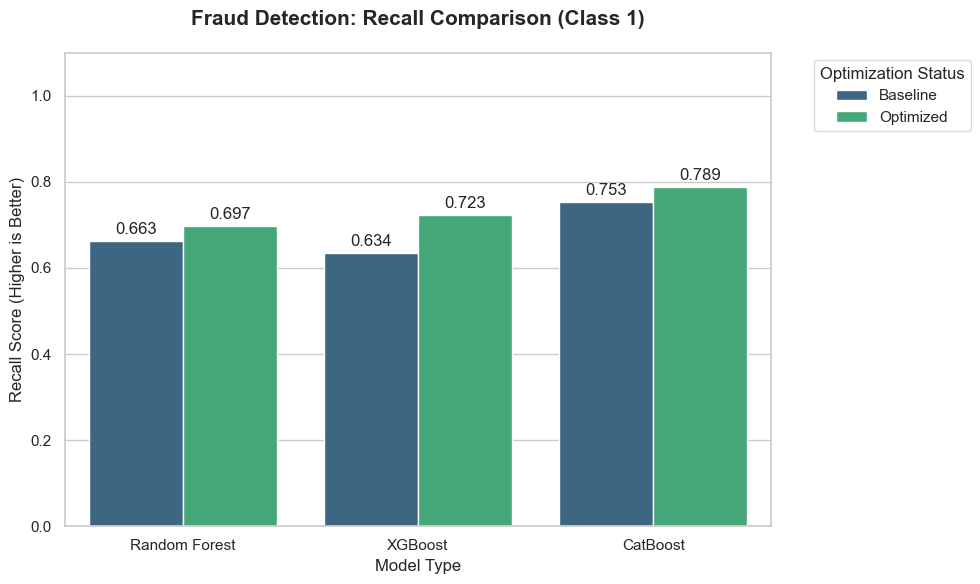

In [193]:
# Plot bar chart to compare the model performance
sns.set_theme(style="whitegrid")


plt.figure(figsize=(10, 6))  # Initialize the figure

# Create the grouped bar chart
ax = sns.barplot(
    data=df_results, 
    x='Model', 
    y='Recall', 
    hue='Type', 
    palette='viridis' 
)

# Add data labels (the numbers) on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

# Add titles and formatting
plt.title('Fraud Detection: Recall Comparison (Class 1)', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Recall Score (Higher is Better)')
plt.xlabel('Model Type')
plt.ylim(0, 1.1)  # Gives extra space at the top for the labels
plt.legend(title='Optimization Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()

***Observation***

Recall refer to "How many actual fraud cases did you catch?" Therefore, high recall indicates comprehensive fraud detection. high recall is vital because missing a single fraudulent transaction (a False Negative) represents a direct financial loss and potential regulatory non-compliance.

The comparison chart demonstrates that hyperparameter optimization improved the recall across all algorithms. CatBoost (Optimized) emerged as the top performer, achieving a recall of 0.789. This means the model successfully identified nearly 80% of all fraudulent attempts, providing the most robust protection against financial risk.  

---

### **Precision🎯**

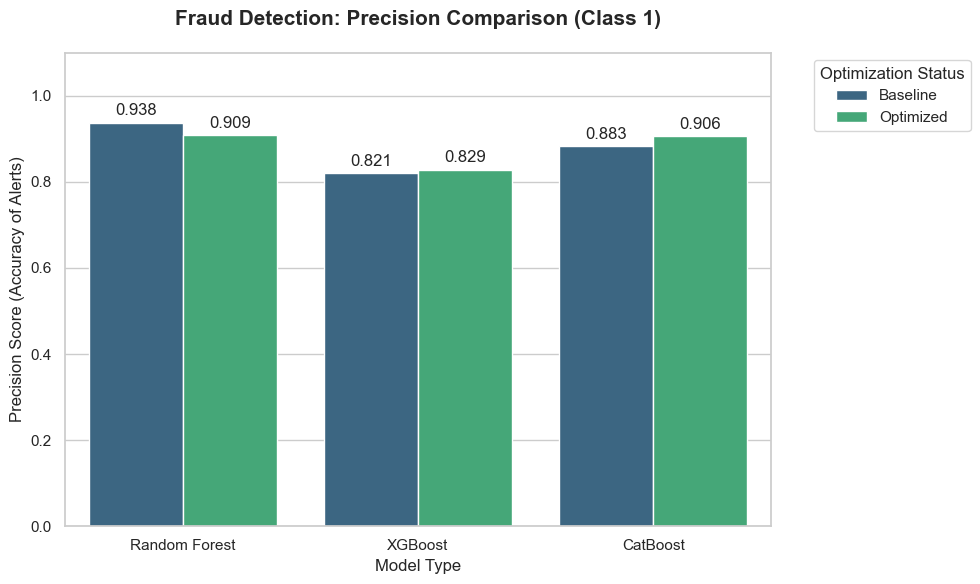

In [197]:
# Plot bar chart to compare the model performance
sns.set_theme(style="whitegrid")


plt.figure(figsize=(10, 6))  # Initialize the figure

# Create the grouped bar chart
ax = sns.barplot(
    data=df_results, 
    x='Model', 
    y='Precision', 
    hue='Type', 
    palette='viridis' 
)

# Add data labels (the numbers) on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

# Titles and Formatting
plt.title('Fraud Detection: Precision Comparison (Class 1)', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Precision Score (Accuracy of Alerts)')
plt.xlabel('Model Type')
plt.ylim(0, 1.1) 
plt.legend(title='Optimization Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# 6. Show the plot
plt.tight_layout()
plt.show()

***Observation***

Precision represents the "quality" of our fraud alerts. It measures the ratio of correctly identified fraud out of all transactions flagged by the model

The comparison chart demonstrates that CatBoost (Optimised) achieved a high precision of 0.906. This indicates that when the model flags a transaction as fraud, it is correct over 90% of the time. Therefore, The Optimized CatBoost model provides the best business value by significantly increasing recall while maintaining a precision level. Moreover, the chart displays that hyperparameter optimisation improved the recall for XGBoost and CatBoost.
However, Random Forest optimised has a decreased precision. This suggests that the model trades off between increasing recall while decreasing precision.


---

### **F1-Score⚖️**

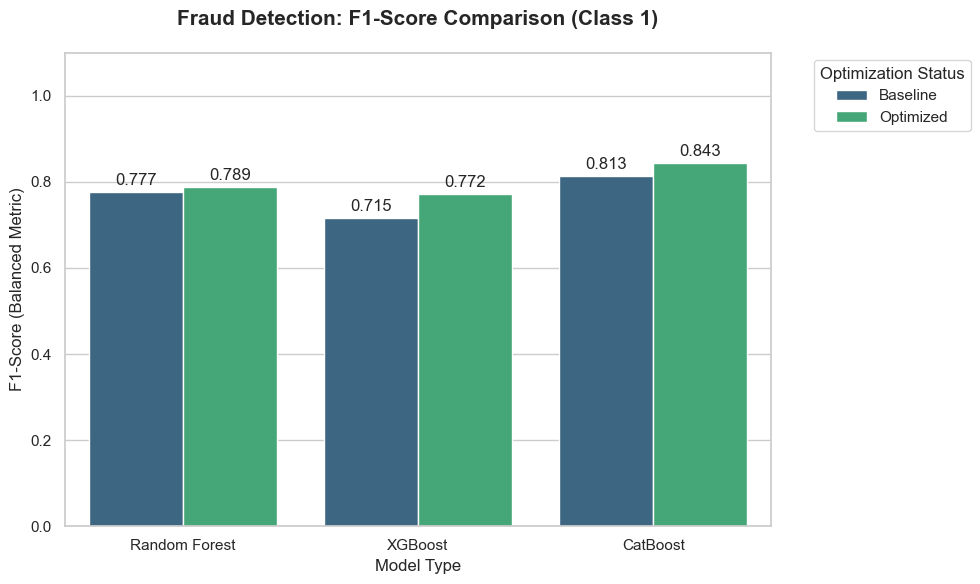

In [201]:
# Plot bar chart to compare the model performance
sns.set_theme(style="whitegrid")


plt.figure(figsize=(10, 6))  # Initialize the figure

# Create the grouped bar chart
ax = sns.barplot(
    data=df_results, 
    x='Model', 
    y='F1-Score', 
    hue='Type', 
    palette='viridis' 
)

# Add data labels (the numbers) on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

# Titles and Formatting
plt.title('Fraud Detection: F1-Score Comparison (Class 1)', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('F1-Score (Balanced Metric)')
plt.xlabel('Model Type')
plt.ylim(0, 1.1) 
plt.legend(title='Optimization Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()

***Observation***

Precision represents harmonic mean of precision and recall to balances detection capability with operational efficiency.

The comparison chart demonstrates that hyperparameter optimization increased the F1-score across all three algorithm. CatBoost (Optimized) reached the highest F1-score of 0.843. This confirms that it offers the best statistical balance between fraud detection and customer experience.


---

### **PR-AUC📈**

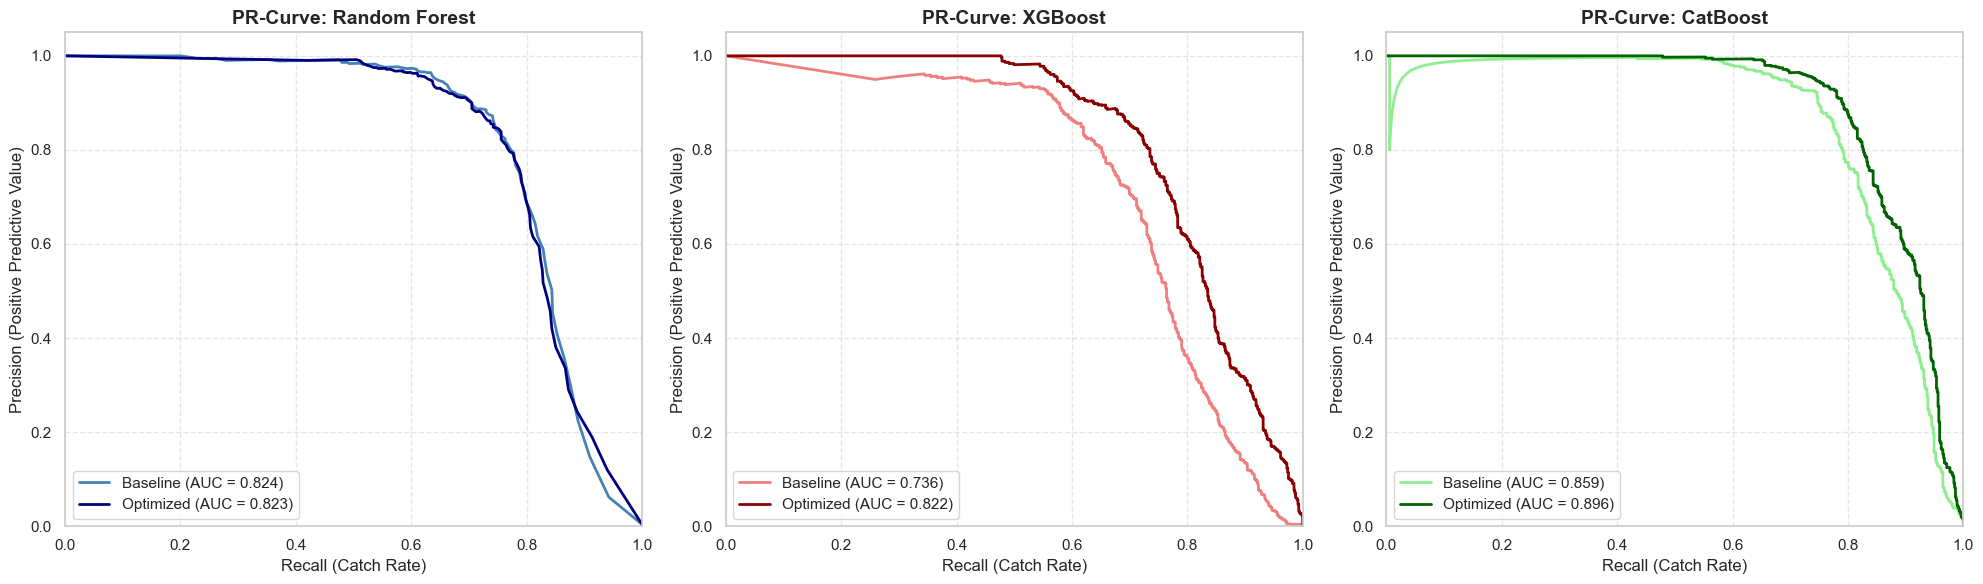

In [205]:
# Plot PR-AUC Chart by comparing between baseline and optimised model
# Group Model 
model_families = {
    'Random Forest': [
        (rfc_baseline, X_val, y_val,'Baseline', 'steelblue'),
        (rfc_optimised, X_val, y_val, 'Optimized', 'navy')
    ],
    'XGBoost': [
        (xgb_baseline, X_val, y_val, 'Baseline', 'lightcoral'),
        (xgb_optimised, X_val, y_val, 'Optimized', 'darkred')
    ],
    'CatBoost': [
        (cat_baseline, X_val_cat, y_val_cat, 'Baseline', 'lightgreen'),
        (cat_optimised, X_val_cat, y_val_cat, 'Optimized', 'darkgreen')
    ]
}

# Create Subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (family_name, variants) in enumerate(model_families.items()):
    ax = axes[i]
    
    for model, x_data, y_data, label, color in variants:
        # Probability
        probs = model.predict_proba(x_data)[:, 1]
        
        # Precision, Recall and PR-AUC
        precision, recall, _ = precision_recall_curve(y_data, probs) 
        pr_auc = auc(recall, precision)
        
        # Plot Charts
        ax.plot(recall, precision, label=f'{label} (AUC = {pr_auc:.3f})', color=color, lw=2)
    
    ax.set_title(f'PR-Curve: {family_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Recall (Catch Rate)')
    ax.set_ylabel('Precision (Positive Predictive Value)')
    ax.legend(loc='lower left')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

***Observation***

PR curves plot Precision against Recall. The PR-AUC plots provide a more realistic picture of model performance in fraud detection scenarios, as they better capture the challenges of detecting rare fraudulent transactions while maintaining reasonable precision. This is particularly important in fraud detection, where both false positives (blocking legitimate transactions) and false negatives (missing fraud) have significant business implications.

Random Forest: The line chart presents very little change between the baseline and optimised versions. 

XGBoost: The chart displays the most significant gap between the light red and dark red lines. Hyperparameter optimisation substantially expanded the area under the curve, proving that XGBoost required careful tuning to unlock its potential.

CatBoost: The chart of the optimised model stays closer to the top-right corner than any other model. It maintains a Precision near 1.0 even as Recall approaches 0.8. This indicates that the model can catch the vast majority of fraud without increasing false alerts.


---

## **6.2) Model Selection**

After comparing the model performance, I selected the optimised model of Catboost as the best-performing model for credit card fraud detection.

In [210]:
cat_optimised.save_model('catboost_fraud_model.cbm')

---

## **6.3) Post-tuning the decision threshold**

Threshold Tuning solves the gap between model scores and business decision. Post-modeling threshold tuning is a crucial step to align a classifier’s predictions with specific business objectives when false positives and false negatives carry different costs like fraud detection where missing fraud is worse than a false alarm. Threshold tuning is trying different cut points on the probability output, rather than accepting the default 0.5 probability cutoff. When you set the cutoff high, you make fewer positive calls and reduce false positives. If you set it low you catch more positives but invite more false alarms. The goal is pick the cutoff that minimizes the harm you care about. 


According to the confusion matrix;
| | Predict Negative | Predict Positive |
|---|:---:|:---:|
| **Actual Negative** | **TN** (True Negative) | **FP** (False Positive) |
| **Actual Positive** | **FN** (False Negative) | **TP** (True Positive) |

**Where:**
* **$TN$ (True Negative):** Legitimate transactions correctly identified ✅
* **$FP$ (False Positives):** Legitimate transactions wrongly flagged (leading to operational investigation costs). (False Alarm)⚠️
* **$FN$ (False Negatives):** Fraudulent transactions missed by the model (direct financial loss).(Missed Fraud)❌
* **$TP$ (True Positives):** Fraudulent transactions correctly identified and blocked. (Caught Fraud)💰


I performed threshold tuning to align with a business strategy that prioritises achieving the highest net savings based on our underlying business assumptions. Therefore, **I consider the cost and benefit from FP (False Alarm), FN (Missed Fraud), and TP(Caught Fraud).**

---

### The Economic Impact Formula🧮 
We define our success by the following profit-based metric:

> **Net Savings** = (Revenue Saved by Catching Fraud) − (Operational Cost from False Alarms) − (Money Lost from Missed Fraud)

$$Net\ Savings = (TP \times R_{TP}) + (TN \times R_{TP}) - (FP \times C_{FP}) - (FN \times C_{FN})$$



### Variable Definitions🔍 
* **$R_{TP}$ (Reward per Caught Fraud):** The value saved by blocking a fraudulent charge. I assume operational savings is 50.00 dollars per transaction.
* **$R_{TN}$ (Reward per successful Payment):** the 2% fee represents the Reward per Successful Payment
* **$C_{FP}$ (Cost per False Alarm):** The operational cost per alert (e.g., customer support time, SMS verification). I assume that operational cost is 10.00 dollars per alert.
* **$C_{FN}$ (Cost per Missed Fraud):** The actual financial loss from the stolen funds and chargebacks. The cost is calculated from the average monetary value of a fraudulent transaction.

### Objective💡 

The goal of post-tuning is to find the Optimal Threshold—the probability threshold that maximises our Net Savings by using TunedThresholdClassifierCV .

---

In [214]:
# Define Business Constants
reward_per_tp = 50                              # Estimate the operational saving 
reward_per_tn = 0.02                            # 2% fee represents the Reward per Successful Payment
cost_per_fp = 10                                # Estimate the operational cost from false alarms  

# Addressing the problem with a business metric
def business_metric(y_true, y_pred, amount):
    mask_true_positive = (y_true == 1) & (y_pred == 1)
    mask_true_negative = (y_true == 0) & (y_pred == 0)
    mask_false_positive = (y_true == 0) & (y_pred == 1)
    mask_false_negative = (y_true == 1) & (y_pred == 0)
    fraudulent_refuse = mask_true_positive.sum() * reward_per_tp
    fraudulent_accept = -amount[mask_false_negative].sum()
    legitimate_refuse = mask_false_positive.sum() * -cost_per_fp
    legitimate_accept = (amount[mask_true_negative] * reward_per_tn).sum()
    return fraudulent_refuse + fraudulent_accept + legitimate_refuse + legitimate_accept

From this business metric, we create a scikit-learn scorer that given a fitted classifier and a test set compute the business metric. In this regard, we use the make_scorer factory. The variable 'amt' is an additional metadata to be passed to the scorer and we need to use metadata routing to take into account this information.

In [219]:
# Enable metadata routing
sklearn.set_config(enable_metadata_routing=True)
business_scorer = make_scorer(business_metric).set_score_request(amount=True)

So at this stage, we observe that the amount of the transaction is used twice: once as a feature to train our predictive model and once as a metadata to compute the the business metric and thus the statistical performance of our model. When used as a feature, we are only required to have a column in data that contains the amount of each transaction. To use this information as metadata, we need to have an external variable that we can pass to the scorer or the model that internally routes this metadata to the scorer

In [221]:
# Treat 'amt' as external variable 
amount_val_cat = df_val_cat["amt"].to_numpy()

### Benefit of CatBoost (Optimised) with default threshold

In [223]:
# Print Benefit of CatBoost with default threshold (0.5)
print(
    "Benefit of CatBoost with default threshold: "
    f"{business_scorer(cat_optimised, X_val_cat, y_val_cat, amount=amount_val_cat):,.2f}$"
)

Benefit of CatBoost with default threshold: 249,137.12$


### Benefit of CatBoost (Optimised) with tuning the decision threshold

In [225]:
# Get the raw fraud probabilities from your best model
y_probs = cat_optimised.predict_proba(X_val_cat)[:, 1]

# Test 100 different thresholds from 0.00 to 1.00
thresholds = np.linspace(0, 1, 101)
benefits = []

for t in thresholds:
    # Convert probabilities to 1 or 0 based on the current threshold 't'
    y_pred_t = (y_probs >= t).astype(int)
    
    # Calculate the total Euro benefit using YOUR function
    total_benefit = business_metric(y_val_cat, y_pred_t, amount=amount_val_cat)
    benefits.append(total_benefit)

# Identify the best performing threshold
max_benefit = max(benefits)
best_threshold = thresholds[np.argmax(benefits)]
benefit_at_50 = benefits[50] # Benefit at the default 0.50 threshold

print(f"Benefit at Default (0.50): ${benefit_at_50:,.2f}")
print(f"Maximum Profit Found: ${max_benefit:,.2f} at Threshold {best_threshold:.2f}")
print(f"Profit Increase: ${(max_benefit - benefit_at_50):,.2f}")

Benefit at Default (0.50): $249,137.12
Maximum Profit Found: $270,753.47 at Threshold 0.09
Profit Increase: $21,616.35


---

## **6.4) Final Evaluation**

After tuning hyperparameters, selecting the best model and tunning threshold by using the validation set, I run the final model on the test set to get the final model performance.

### Final Evaluation of CatBoost (Optimised) with default threshold

In [227]:
# Treat 'amt' as external variable 
amount_test_cat = df_test_cat["amt"].to_numpy()

In [229]:
# Prediction and Evaluation Metrices
y_predicted = cat_optimised.predict(X_test_cat)
benefit_at_50 = business_metric(y_test_cat, y_predicted, amount=amount_test_cat)

# Print Statistical Metrics
print(f"FINAL TEST SET PERFORMANCE")
print(f"-------------------------------------------------------")
print(f"Total Business Benefit (Default 0.5) : ${benefit_at_50:,.2f}")

FINAL TEST SET PERFORMANCE
-------------------------------------------------------
Total Business Benefit (Default 0.5) : $482,895.77


### Final Evaluation of CatBoost (Optimised) with optimised threshold

FINAL TEST SET PERFORMANCE (Threshold: 0.09)
-------------------------------------------------------
Total Business Benefit (Optimized) : $525,154.31
Total Business Benefit (Default 0.5) : $482,895.77
PROFIT INCREASE : $42,258.54 
-------------------------------------------------------
ROC AUC Score          : 0.9974
Average Precision      : 0.9039
Training time          : 114.4013 seconds

Classification Report (Optimized):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    365359
           1       0.57      0.90      0.70      1416

    accuracy                           1.00    366775
   macro avg       0.78      0.95      0.85    366775
weighted avg       1.00      1.00      1.00    366775



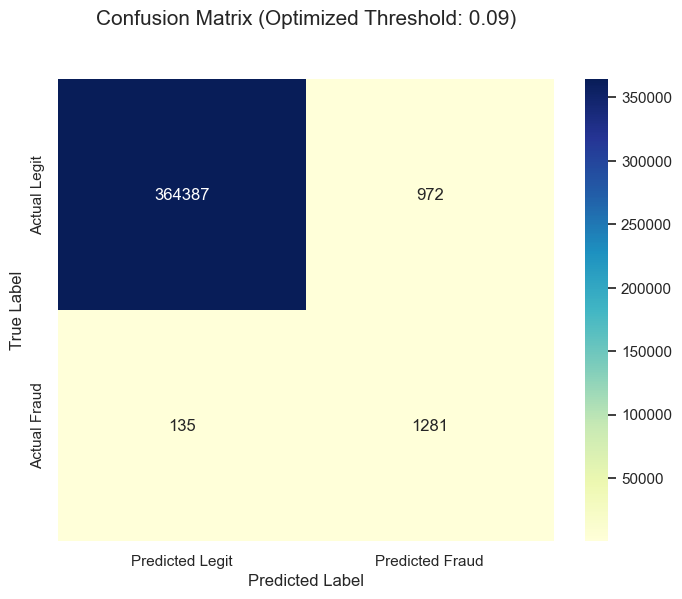

In [231]:
# 1. Generate Probabilities and apply the OPTIMAL threshold
y_probs_test = cat_optimised.predict_proba(X_test_cat)[:, 1]
y_pred_final = (y_probs_test >= best_threshold).astype(int)

# 2. Calculate Financial Value (Using your business_metric function)
final_business_value = business_metric(y_test_cat, y_pred_final, amount=amount_test_cat)

# 3 Profit increase between before and after tuning threshold
profit_increase = final_business_value - benefit_at_50

# Print Statistical Metrics
print(f"FINAL TEST SET PERFORMANCE (Threshold: {best_threshold:.2f})")
print(f"-------------------------------------------------------")
print(f"Total Business Benefit (Optimized) : ${final_business_value:,.2f}")
print(f"Total Business Benefit (Default 0.5) : ${benefit_at_50:,.2f}")
print(f"PROFIT INCREASE : ${profit_increase:,.2f} ") 
print(f"-------------------------------------------------------")
print(f"ROC AUC Score          : {roc_auc_score(y_test_cat, y_probs_test):.4f}")
print(f"Average Precision      : {average_precision_score(y_test_cat, y_probs_test):.4f}")
print(f"Training time          : {train_time:.4f} seconds")
print('\nClassification Report (Optimized):\n', classification_report(y_test_cat, y_pred_final))

# Plot the Business-Optimized Confusion Matrix
plt.figure(figsize=(8, 6))
cnf_matrix = confusion_matrix(y_test_cat, y_pred_final)

# Create a DataFrame for Seaborn heatmap
df_cm = pd.DataFrame(cnf_matrix, index=['Actual Legit', 'Actual Fraud'], 
                     columns=['Predicted Legit', 'Predicted Fraud'])

sns.heatmap(df_cm, annot=True, cmap="YlGnBu", fmt='g')
plt.title(f'Confusion Matrix (Optimized Threshold: {best_threshold:.2f})', y=1.1, fontsize=15)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

After I have selected the Catboost optimised model as the best performing model. I perform tuning threshold based on the business assumption and found the best threshold at 0.09. By moving the threshold from 0.50 down to 0.09, we can increase the benefit by $42k from the same dataset. Moreover, the model tends to be highly sensitive, with the recall reaching 0.9. It means we can identify 90% of all fraud cases. While the precision is 0.57. Because the cost of a missed fraud (FN) is much higher than the cost of checking a good customer (FP). Therefore, the model prioritises to save the money from those extra caught frauds. Moreover, ROC AUC and Average Precision reach to 0.9974 and 0.9039, respectively. These scores confirm the high performance of model. 

However, the optimised threshold can vary based on the business strategy. Therefore, we should reconsider and monitor the assumption of the model regulary. 

<hr style="border: none; border-top: 5px double #333;">

# **7. Model Deployment**

## **7.1) Deployment Strategy**

Deploying fraud detection models requires a real-time, low-latency architecture, typically utilizing tools. Tools like Apache Kafka, Spark Streaming, or Flink are commonly used to capture this data in real time.

## **7.2) Model Monitoring & Maintenance**

The fraud detection system must be monitored continuously. Therefore, we should monitor technical, model, and business.
- Technical Monitoring: We should ensure the fraud detection system is running smoothly.
- Model Monitoring: We should monitor the ML model to continue making good decisions.
- Business Monitoring: We should ensure the model outputs are algin with the business key performance indicator. Moreover, we should ask a domain expert such as an auditor or fraud analyst, for manual review and get the feedback to improve model performance.

<hr style="border: none; border-top: 5px double #333;">

# **Reference**

Ashington. (2025). ML system design for fraud detection in real-time. Medium. https://ashington.medium.com/ml-system-design-for-fraud-detection-in-real-time-cef7c5526899

Chandrasekaran, C. (n.d.). EDA for a classification problem. Deepnote. https://deepnote.com/app/charan-chandrasekaran/EDA-for-Classification-problem-df3d55a6-09d3-48ec-8aca-d039a4b5ff5a

Coursera. (2025). Data preprocessing steps: How to prepare data for machine learning and analytics. https://www.coursera.org/articles/data-preprocessing-steps

GeeksforGeeks. (2022). Haversine formula to find the distance between two points on a sphere. https://www.geeksforgeeks.org/haversine-formula-to-find-distance-between-two-points-on-a-sphere/

GeeksforGeeks. (2025). Label encoding of datasets in python. https://www.geeksforgeeks.org/ml-label-encoding-of-datasets-in-python/

GeeksforGeeks. (2026). Random Forest algorithm in machine learning. https://www.geeksforgeeks.org/random-forest-algorithm-in-machine-learning/

GeeksforGeeks. (2025). What is feature engineering? https://www.geeksforgeeks.org/what-is-feature-engineering/

GeeksforGeeks. (2026). XGBoost. https://www.geeksforgeeks.org/xgboost/

Olaniyan, B. (2025). Sklearn vs. Imblearn pipeline: Preventing data leakage in imbalanced datasets. Medium. https://medium.com/@banjiolaniyan123/sklearn-vs-imblearn-pipeline-preventing-data-leakage-in-imbalanced-datasets-b4272484e985

Pykes, K. (2025). Data preprocessing: A complete guide with Python examples. DataCamp. https://www.datacamp.com/blog/data-preprocessing

Sanjay V. (2024). What is EDA? Medium. https://medium.com/@sanjayskumar4010/what-is-eda-1abdae6409bf

Scikit-learn. (n.d.). Metrics and scoring: Quantifying the quality of predictions. https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-string-names

Scikit-learn. (n.d.). Post-tuning the decision threshold for cost-sensitive learning. https://scikit-learn.org/stable/auto_examples/model_selection/plot_cost_sensitive_learning.html

Shenoy, K. (2020). Credit card transactions fraud detection dataset [Data set]. Kaggle. https://www.kaggle.com/datasets/kartik2112/fraud-detection

Stack Overflow. (2016). How to tune parameters in random forest using scikit-learn. https://stackoverflow.com/questions/36107820/how-to-tune-parameters-in-random-forest-using-scikit-learn

Talent500. (n.d.). Feature engineering: Creating new features to enhance model performance. https://talent500.com/blog/feature-engineering-creating-new-features-to-enhance-model-performance/

Verzi, V. (2025). Understanding model evaluation metrics in fraud detection: Beyond accuracy. Medium. https://medium.com/@valeria.verzi1/understanding-model-evaluation-metrics-in-fraud-detection-beyond-accuracy-52b224ac0418

<hr style="border: none; border-top: 5px double #333;">